In [5]:
import numpy as np 
import pandas as pd
import astropy
from astropy.io import fits
import matplotlib.pyplot as plt
import scipy as sp 
from scipy.stats import poisson

import seaborn as sns
plt.style.use('dark_background')
plt.rcParams['axes.facecolor'] = 'midnightblue'
plt.rcParams['figure.facecolor'] = "#060552"
plt.rcParams['axes.grid'] = 'True'
plt.rcParams['grid.color'] = 'steelblue'
plt.rcParams['grid.linewidth'] = 0.6
plt.rcParams['grid.alpha'] = 0.8
plt.rcParams['axes.edgecolor'] = 'white'
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['legend.facecolor'] = "#060552"

This will be the starting notebook file for assignment # 1

In [6]:
gaia_file = '/Users/leayamashiro/AnA_MSc/Period_3_2026/phys_statistics/assignments/data/gaia_data.fits'

In [7]:
dr3stars = fits.open(gaia_file)
dr3stars.info()
print(dr3stars[1].columns)
stars = pd.DataFrame(dr3stars[1].data)
stars['Name'] = stars['Name'].str.strip()

Filename: /Users/leayamashiro/AnA_MSc/Period_3_2026/phys_statistics/assignments/data/gaia_data.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      93   ()      
  1  members.dat    1 TableHDU       331   1291929R x 56C   [A20, I4, I19, I1, F10.8, F12.8, F10.8, F12.8, F10.8, F12.8, E11.4, E11.4, F10.8, E11.4, F10.8, E11.4, F10.8, F11.8, F11.8, E11.4, E11.4, E11.4, E11.4, E11.4, E11.4, I2, F12.8, F10.7, F11.8, F10.8, F19.8, F16.8, F18.8, F17.8, F18.8, F17.8, F10.7, F10.7, F10.7, E11.4, E11.4, E11.4, E9.3, F12.8, F4.1, F6.1, F5.1, F11.7, F11.8, F6.1, F12.7, F13.8, F5.1, A13, I1, I1]   
ColDefs(
    name = 'Name'; format = 'A20'; start = 1
    name = 'ID'; format = 'I4'; disp = 'I4'; start = 22
    name = 'GaiaDR3'; format = 'I19'; disp = 'I19'; start = 27
    name = 'inrt'; format = 'I1'; disp = 'I1'; start = 47
    name = 'Prob'; format = 'F10.8'; disp = 'F10.8'; start = 49
    name = 'RAdeg'; format = 'F12.8'; unit = 'deg'; disp = 'F12

In [8]:
stars
# okay so each row is a star, 

,Name,ID,GaiaDR3,inrt,Prob,RAdeg,e_RAdeg,DEdeg,e_DEdeg,GLON,...,o_RVd,GRVSmag,e_GRVSmag,o_GRVSmag,Vbroad,e_Vbroad,o_Vbroad,VarFlag,NSS,RVS
0,1636-283,0,6032349260227596544,0,0.747692,249.708525,0.201080,-28.585117,0.115789,351.679705,...,0.0,0.00000,0.000000,0.0,0.00000,0.000000,0.0,NOT_AVAILABLE,0,0
1,1636-283,0,6032358331198284160,1,1.000000,249.866424,0.020684,-28.402037,0.013691,351.914287,...,8.0,0.00000,0.000000,0.0,0.00000,0.000000,0.0,NOT_AVAILABLE,0,0
2,1636-283,0,6032358331198285696,1,0.843798,249.865221,0.046356,-28.399406,0.029595,351.915643,...,0.0,0.00000,0.000000,0.0,0.00000,0.000000,0.0,NOT_AVAILABLE,0,0
3,1636-283,0,6032358331198286080,1,1.000000,249.861159,0.045101,-28.400698,0.030237,351.912273,...,0.0,0.00000,0.000000,0.0,0.00000,0.000000,0.0,NOT_AVAILABLE,0,0
4,1636-283,0,6032358670488486784,1,1.000000,249.939480,0.038724,-28.429366,0.023344,351.935370,...,0.0,0.00000,0.000000,0.0,0.00000,0.000000,0.0,NOT_AVAILABLE,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1291924,vdBergh_92,7163,3045840104515988992,1,1.000000,106.116546,0.110176,-11.474387,0.111851,224.621323,...,0.0,0.00000,0.000000,0.0,0.00000,0.000000,0.0,NOT_AVAILABLE,0,0
1291925,vdBergh_92,7163,3045840074455065088,1,0.838193,106.136236,0.049847,-11.471452,0.049169,224.627544,...,0.0,0.00000,0.000000,0.0,0.00000,0.000000,0.0,NOT_AVAILABLE,0,0
1291926,vdBergh_92,7163,3045840074453671680,1,0.639341,106.135606,0.056229,-11.468653,0.058581,224.624770,...,0.0,0.00000,0.000000,0.0,0.00000,0.000000,0.0,VARIABLE,0,0
1291927,vdBergh_92,7163,3045840654267074048,1,0.738133,106.159649,0.058318,-11.436082,0.062037,224.606570,...,0.0,0.00000,0.000000,0.0,0.00000,0.000000,0.0,NOT_AVAILABLE,0,0


In [9]:
clcounts = stars.groupby(['Name']).size().reset_index(name='count')
clcounts

,Name,count
0,1636-283,38
1,ADS_16795,41
2,AH03_J0748+26.9,68
3,ASCC_100,87
4,ASCC_101,224
...,...,...
7162,vdBergh_152,25
7163,vdBergh_80,93
7164,vdBergh_83,92
7165,vdBergh_85,105


In [10]:
data_explain = pd.read_fwf(
    "data_description.txt",
    colspecs=[ # overkill but just so I can look at it as a table
        (0, 8),    # Bytes
        (9, 15),   # Format
        (16, 22),   # Units
        (23, 36),   # Label
        (37, 82)  # Explanations 
        ], 
        names=["Bytes", "Format", "Units", "Label", "Explanations"]
)
data_explain = data_explain.dropna(subset=["Bytes"])
data_explain = data_explain[data_explain["Bytes"].str.contains(r"\d", na=False)]
data_explain = data_explain.reset_index(drop=True)
data_explain

,Bytes,Format,Units,Label,Explanations
0,1- 15,F15.11,deg,RAdeg,[] Gaia DR2 right ascension (ICRS)
1,17- 31,F15.11,deg,DEdeg,Gaia DR2 declination (ICRS)
2,33- 51,I19,---,Source,Gaia DR2 source_id (source_id)
3,53- 66,F14.10,deg,GLON,[] Gaia DR2 Galactic longitude (l)
4,68- 81,F14.10,deg,GLAT,Gaia DR2 Galactic latitude (b)
5,83- 92,F10.4,mas,plx,Gaia DR2 parallax (parallax)
6,94- 99,F6.4,mas,e_plx,Gaia DR2 parallax error (parallax_error)
7,101-109,F9.3,mas/yr,pmRA,Gaia DR2 proper motion along RA (pmra)
8,111-115,F5.3,mas/yr,e_pmRA,Gaia DR2 pmRA error (pmra_error)
9,117-125,F9.3,mas/yr,pmDE,Gaia DR2 proper motion along DE (pmdec)


Writing these questions before I start! 

- difference between `Gaia DR2 correlation factor (ra_dec_corr)` and `Gaia DR2 correlation factor`? (Row 11-12)
- what kind of correlation factors? are they the Fourier kind (for interferometry)? What are these for? and how are they calculated?? 
- what is `inrt`?
- are any stars candidates for multiple clusters? (to answer this: how far apart in degree are the clusters (of known cluster stars)) 
- are all stars in this type of catalogues *all* technically "candidates"? or no. 

### 1. Exploratory Data Analysis (6 pts): The parameter `Prob` gives a conservative estimate of the probability that the star is associated with the cluster, by doing a "clustering" analysis of the stars in the 5-dimensional astrometric parameter space, i.e. using `RAdeg`, `DEdeg`, `Plx`, `pmRA` and `pmDE`.

 **a. Use the Pandas sample function on your cluster star counts dataframe, to randomly select 4 clusters, only from clusters with >1000 candidate stars. Please make sure to include the random seed you used in the notebook for reproducibility. Be sure to include the names of the clusters in your notebook!**

In [11]:
# organizing cluster for sampling
clcount_gt1000 = clcounts[clcounts['count']>1000] 
clcount_gt1000.sort_values('count', ascending = False)

,Name,count
5921,Theia_6046,153797
4638,NGC_5139,65987
4731,NGC_6397,27910
4600,NGC_3201,25448
4678,NGC_6121,22191
...,...,...
3773,HSC_561,1067
4331,King_11,1056
4553,NGC_2447,1043
4701,NGC_6253,1022


Note: I used `np.random.choice` here before I learned about the `np.random.seed()` function and how that works. To compensate for the fact that I did not correctly seed my selection, I saved the random 4 clusters that I got below, and used them directly as a list when I was selecting the sample so that the code should work the same way. 

In [12]:
# np.random.seed(42)

In [13]:
# doing number selection here, immediately to report in cell below
random_4cl = np.random.choice(clcount_gt1000['Name'], size=4)
# print(random_4cl) 
# not going to be same obviously

**My random selection is: ['NGC_6402' 'NGC_1039' 'NGC_362' 'Trumpler_20']**

In [ ]:
cl_4sample = clcount_gt1000[clcount_gt1000['Name'].isin(['NGC_6402', 'NGC_1039', 'NGC_362', 'Trumpler_20'])]
print('Cluster Count Sample:')
cl_4sample

Cluster Count Sample:


,Name,count
4438,NGC_1039,1095
4611,NGC_362,8941
4734,NGC_6402,1337
6054,Trumpler_20,1692


In [15]:
stars_cl4sample = stars[stars['Name'].isin(['NGC_6402', 'NGC_1039', 'NGC_362', 'Trumpler_20'])]
print('Stars, Cluster-Sampled:')
stars_cl4sample

Stars, Cluster-Sampled:


,Name,ID,GaiaDR3,inrt,Prob,RAdeg,e_RAdeg,DEdeg,e_DEdeg,GLON,...,o_RVd,GRVSmag,e_GRVSmag,o_GRVSmag,Vbroad,e_Vbroad,o_Vbroad,VarFlag,NSS,RVS
358296,NGC_1039,4465,337182734061484800,1,0.683711,40.882332,0.210117,42.985478,0.191451,143.805824,...,0.0,0.000000,0.000000,0.0,0.00000,0.00000,0.0,NOT_AVAILABLE,0,0
358297,NGC_1039,4465,337181497110912640,0,0.293323,40.907782,0.044749,42.913126,0.032604,143.855767,...,1.0,13.791054,0.151417,11.0,0.00000,0.00000,0.0,NOT_AVAILABLE,0,0
358298,NGC_1039,4465,337182253025154432,1,0.792008,40.827758,0.124072,42.948665,0.128915,143.785038,...,0.0,0.000000,0.000000,0.0,0.00000,0.00000,0.0,NOT_AVAILABLE,0,0
358299,NGC_1039,4465,337182253025154176,1,0.947186,40.815251,0.022586,42.952296,0.017556,143.774850,...,5.0,10.628771,0.010978,10.0,70.94052,41.44001,8.0,NOT_AVAILABLE,0,0
358300,NGC_1039,4465,337182081226227968,1,0.675653,40.790763,0.031549,42.901138,0.026688,143.781032,...,4.0,14.039725,0.043173,11.0,0.00000,0.00000,0.0,NOT_AVAILABLE,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1178027,Trumpler_20,6058,6056572978895876480,0,0.354653,189.120301,0.027207,-60.639154,0.029132,301.098231,...,0.0,0.000000,0.000000,0.0,0.00000,0.00000,0.0,NOT_AVAILABLE,0,0
1178028,Trumpler_20,6058,6056573356853054208,0,0.348934,189.127909,0.037502,-60.615378,0.038671,301.100579,...,0.0,0.000000,0.000000,0.0,0.00000,0.00000,0.0,NOT_AVAILABLE,0,0
1178029,Trumpler_20,6058,6056574250176174208,0,0.362308,189.425865,0.069694,-60.566020,0.075876,301.244024,...,0.0,0.000000,0.000000,0.0,0.00000,0.00000,0.0,NOT_AVAILABLE,0,0
1178030,Trumpler_20,6058,6056574314578215296,0,0.351197,189.340747,0.076994,-60.585221,0.081446,301.203274,...,0.0,0.000000,0.000000,0.0,0.00000,0.00000,0.0,NOT_AVAILABLE,0,0


 **b:** Split each cluster into two subsamples corresponding to  stars with Prob ≤ 0.8 and stars with Prob > 0.8 and for each cluster, make a scatter plot matrix (see the extras episode, or use libraries that have this functionality like corner or seaborn) to show on the same figure the data points for both subsamples on this 5-D parameter space. Use the same axis limits for both Prob ≤ 0.8 and Prob > 0.8 and use transparency (alpha < 0 3).

In [132]:
cl4stars_P_ltp8 = stars_cl4sample[stars_cl4sample['Prob']<=0.8] # less than 0.8 probability
cl4stars_P_gtp8 = stars_cl4sample[stars_cl4sample['Prob']>0.8] # less than 0.8 probability
print("Cluster candidates with P < 0.8 (whole table):")
cl4stars_P_ltp8

Cluster candidates with P < 0.8 (whole table):


,Name,ID,GaiaDR3,inrt,Prob,RAdeg,e_RAdeg,DEdeg,e_DEdeg,GLON,...,o_RVd,GRVSmag,e_GRVSmag,o_GRVSmag,Vbroad,e_Vbroad,o_Vbroad,VarFlag,NSS,RVS
358296,NGC_1039,4465,337182734061484800,1,0.683711,40.882332,0.210117,42.985478,0.191451,143.805824,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
358297,NGC_1039,4465,337181497110912640,0,0.293323,40.907782,0.044749,42.913126,0.032604,143.855767,...,1.0,13.791054,0.151417,11.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
358298,NGC_1039,4465,337182253025154432,1,0.792008,40.827758,0.124072,42.948665,0.128915,143.785038,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
358300,NGC_1039,4465,337182081226227968,1,0.675653,40.790763,0.031549,42.901138,0.026688,143.781032,...,4.0,14.039725,0.043173,11.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
358301,NGC_1039,4465,337183008939390976,0,0.426275,40.983133,0.353317,42.966198,0.289891,143.883376,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1178027,Trumpler_20,6058,6056572978895876480,0,0.354653,189.120301,0.027207,-60.639154,0.029132,301.098231,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
1178028,Trumpler_20,6058,6056573356853054208,0,0.348934,189.127909,0.037502,-60.615378,0.038671,301.100579,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
1178029,Trumpler_20,6058,6056574250176174208,0,0.362308,189.425865,0.069694,-60.566020,0.075876,301.244024,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
1178030,Trumpler_20,6058,6056574314578215296,0,0.351197,189.340747,0.076994,-60.585221,0.081446,301.203274,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0


In [17]:
# stars, cluster 4 sample, 5 parameter space (but keep names for organizing)

# greater than 0.8 probability of sample cluster stars
GTp8_cl4stars = cl4stars_P_gtp8[['Name', 'RAdeg', 'DEdeg', 'Plx', 'pmRA', 'pmDE']]
# less than 0.8 probability of sample cluster stars
LTp8_cl4stars = cl4stars_P_ltp8[['Name', 'RAdeg', 'DEdeg', 'Plx', 'pmRA', 'pmDE']]

print('Less than Prob = 0.8 cluster candidates in speciifc paramter space:')
LTp8_cl4stars

Less than Prob = 0.8 cluster candidates in speciifc paramter space:


,Name,RAdeg,DEdeg,Plx,pmRA,pmDE
358296,NGC_1039,40.882332,42.985478,1.9870,1.1610,-5.9890
358297,NGC_1039,40.907782,42.913126,1.9350,-0.3740,-4.9640
358298,NGC_1039,40.827758,42.948665,2.0790,0.4056,-5.7490
358300,NGC_1039,40.790763,42.901138,2.0180,1.2210,-5.7240
358301,NGC_1039,40.983133,42.966198,2.2040,0.5924,-5.4340
...,...,...,...,...,...,...
1178027,Trumpler_20,189.120301,-60.639154,0.3222,-7.0020,0.3915
1178028,Trumpler_20,189.127909,-60.615378,0.1734,-7.2160,0.2778
1178029,Trumpler_20,189.425865,-60.566020,0.2789,-7.0060,0.4154
1178030,Trumpler_20,189.340747,-60.585221,0.2354,-6.9800,0.2868


In [18]:
# writing function to plot for each

def cluster_scatter_matrix(cluster_name, lt_df, gt_df, labels): 
    # select just the info for specific cluster, drop the name column
    ltp8_cluster_spec = lt_df[lt_df['Name'] == cluster_name].drop(columns = 'Name')
    gtp8_cluster_spec = gt_df[gt_df['Name'] == cluster_name].drop(columns = 'Name')
    # turn to numpy arrays for indexing 
    ltp8_cluster_array = ltp8_cluster_spec.to_numpy()
    gtp8_cluster_array = gtp8_cluster_spec.to_numpy()
    # labels = LTp8_cl4stars.columns
    fig, axes = plt.subplots(5,5, figsize = (15,15))
    fig.subplots_adjust(wspace = 0.3, hspace = 0.3)

    for i in range(ltp8_cluster_array.shape[1]): # y dimension of grid
        for j in range(gtp8_cluster_array.shape[1]): # x dimension of grid 
            if i == j: 
                axes[i,j].hist(ltp8_cluster_array[:,i], density = 'True', bins = 10, alpha = 0.5, color = 'yellow', label = 'P < 0.8')
                axes[i,j].hist(gtp8_cluster_array[:,i], density = 'True', bins = 10, alpha = 0.5, color = 'deeppink', label = 'P > 0.8')
            elif i > j: # lower triangle panels 
                axes[i,j].scatter(ltp8_cluster_array[:,j], ltp8_cluster_array[:,i], alpha = 0.5, s = 1, color = 'yellow', label = 'P < 0.8')
                axes[i,j].scatter(gtp8_cluster_array[:,j], gtp8_cluster_array[:,i], alpha = 0.5, s = 1, color = 'deeppink', label = 'P > 0.8')
            else: 
                axes[i,j].axis('off')
            if j == 0: 
                if i == j: 
                    axes[i,j].set_ylabel('counts', fontsize = 12) 
                else: 
                    axes[i,j].set_ylabel(labels[i], fontsize = 12)
            if i == 4: 
                axes[i,j].set_xlabel(labels[j], fontsize = 12)
        # more for plotting 
        count = cl_4sample[cl_4sample["Name"] == cluster_name]["count"].values[0]
        
    # legend stuff 
    handles, labels = axes[0, 0].get_legend_handles_labels()

    fig.legend(
            handles,
            labels,
            bbox_to_anchor=(0.975, 0.75),
            frameon=True,
            fontsize=20,)
        
    plt.suptitle(f'Cluster: {cluster_name}, Candidate Count = {count}', fontsize = 25)
    plt.tight_layout()

        


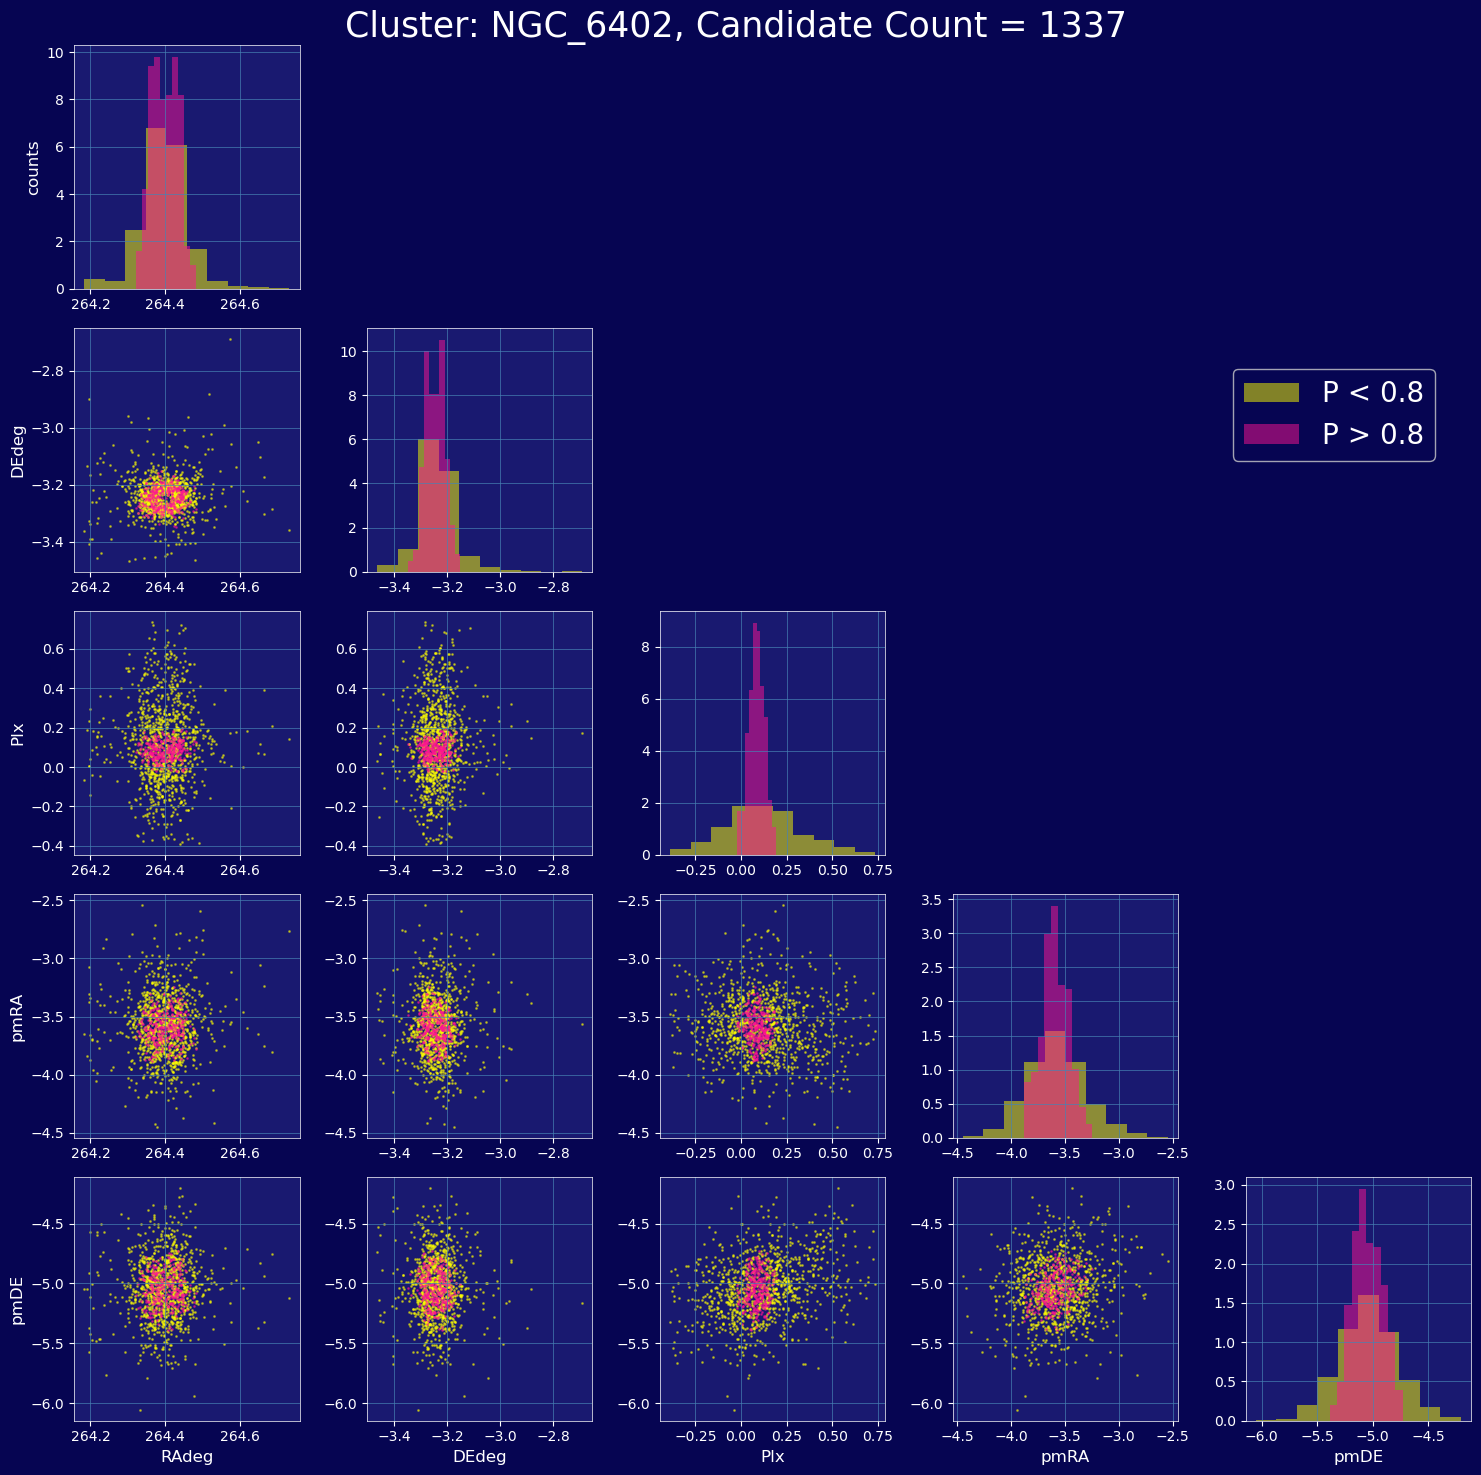

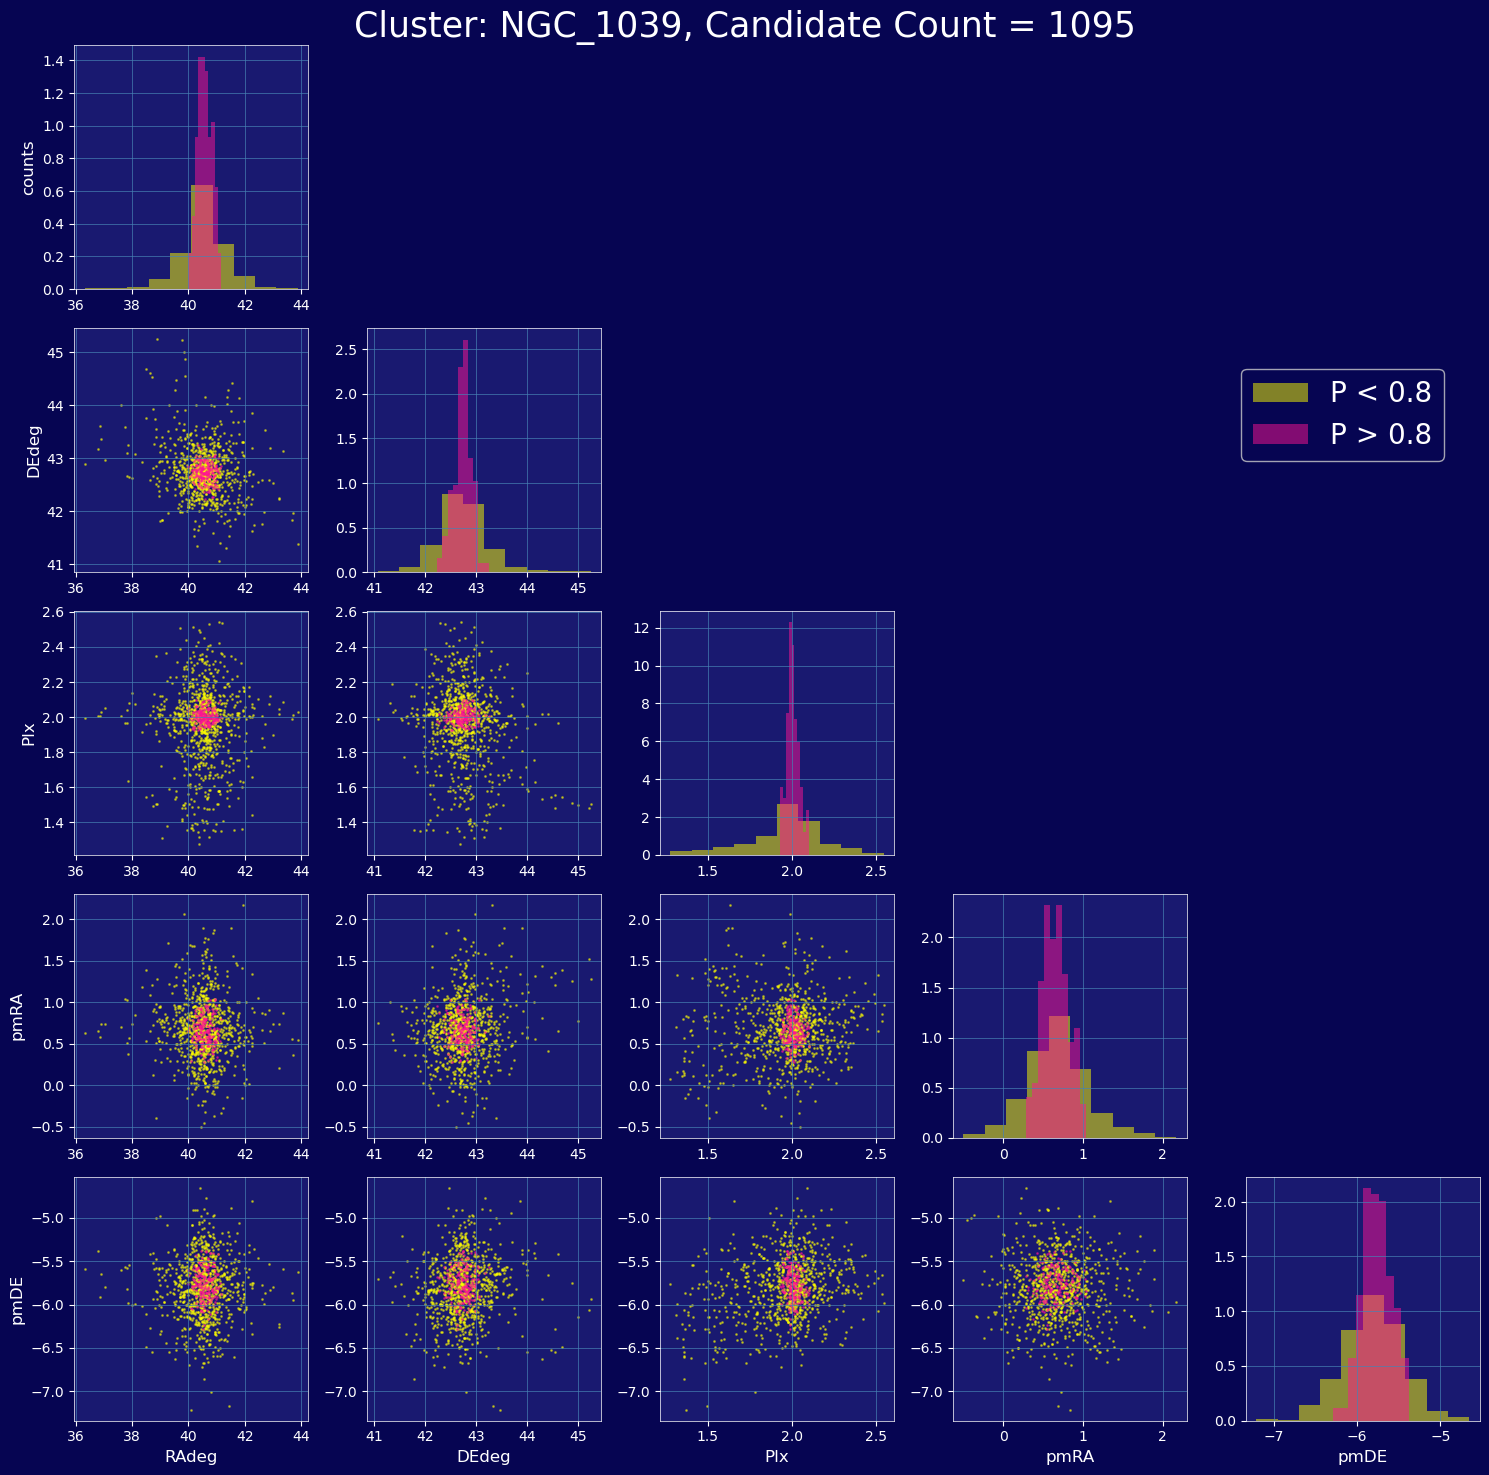

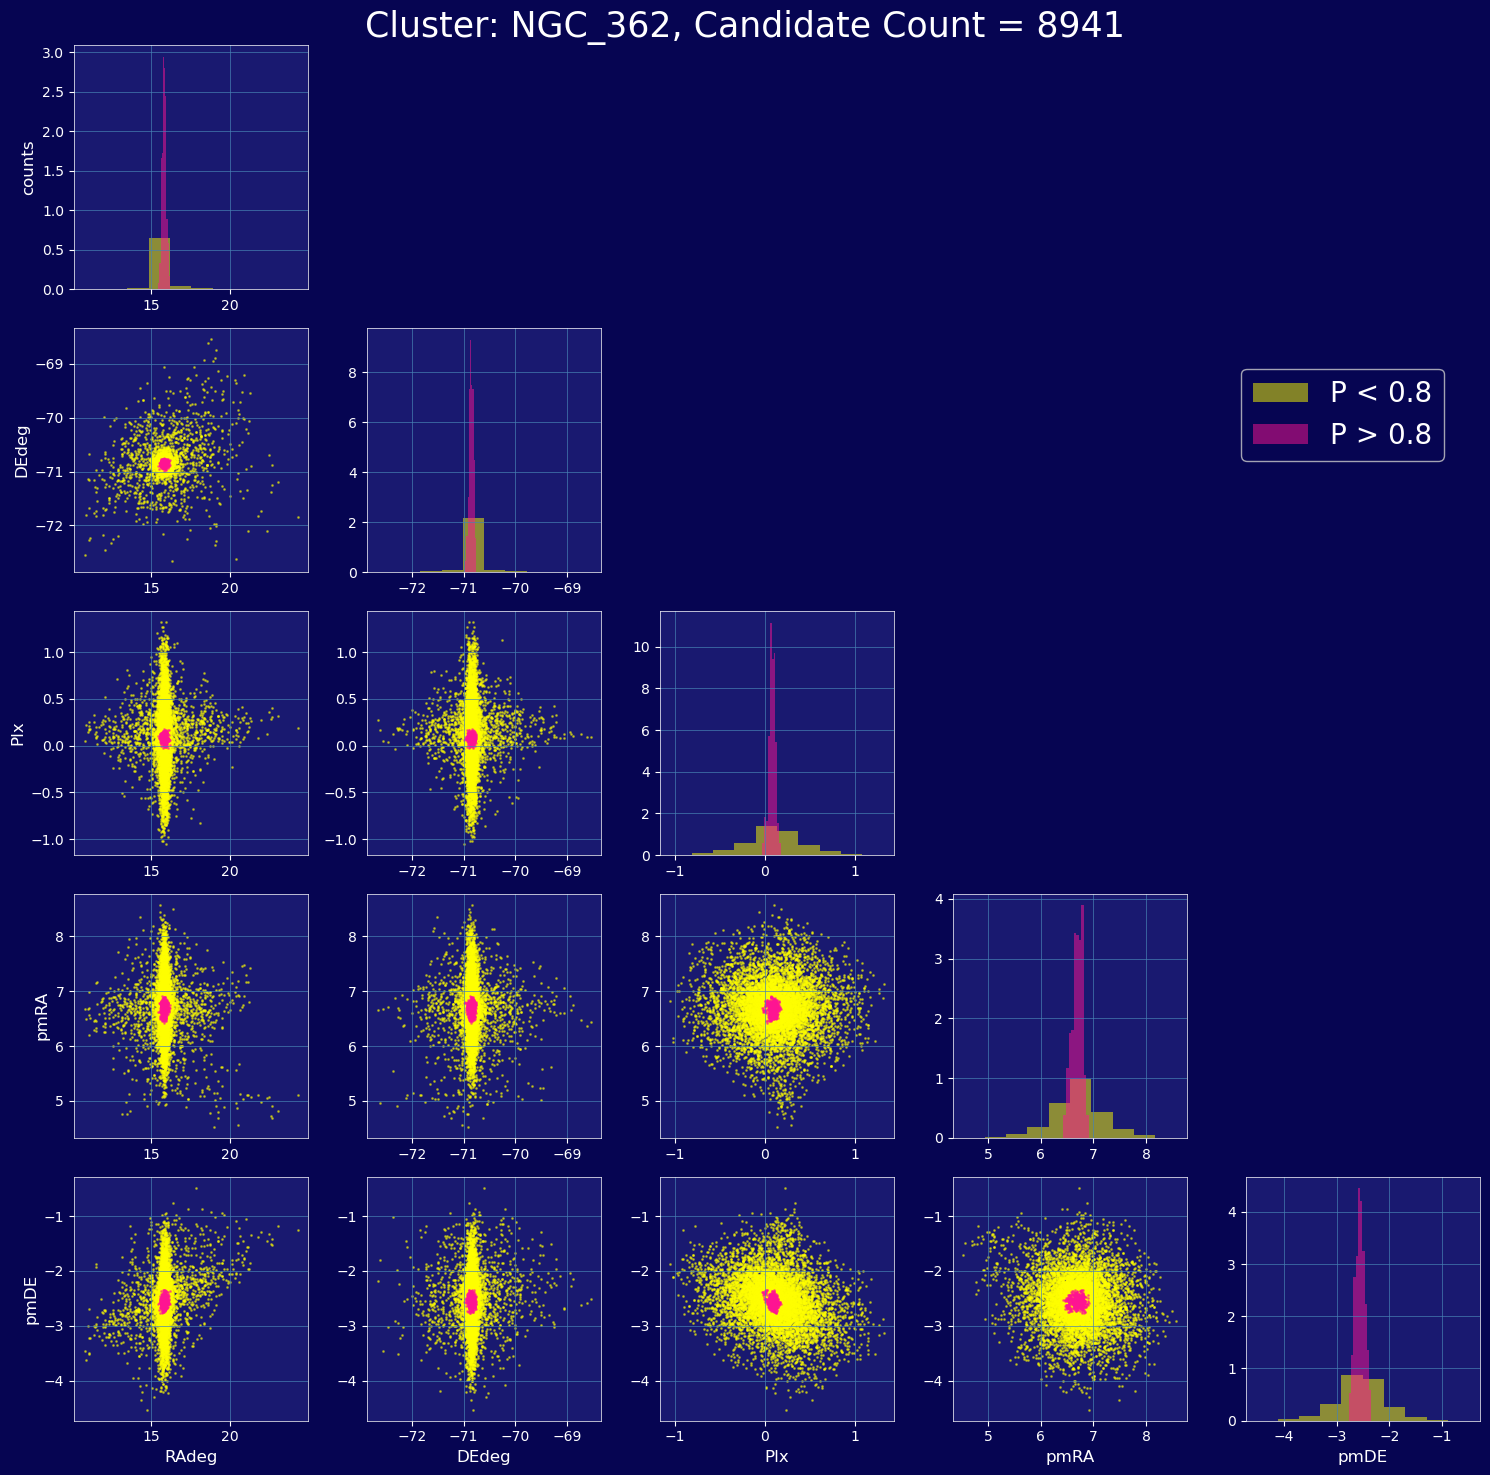

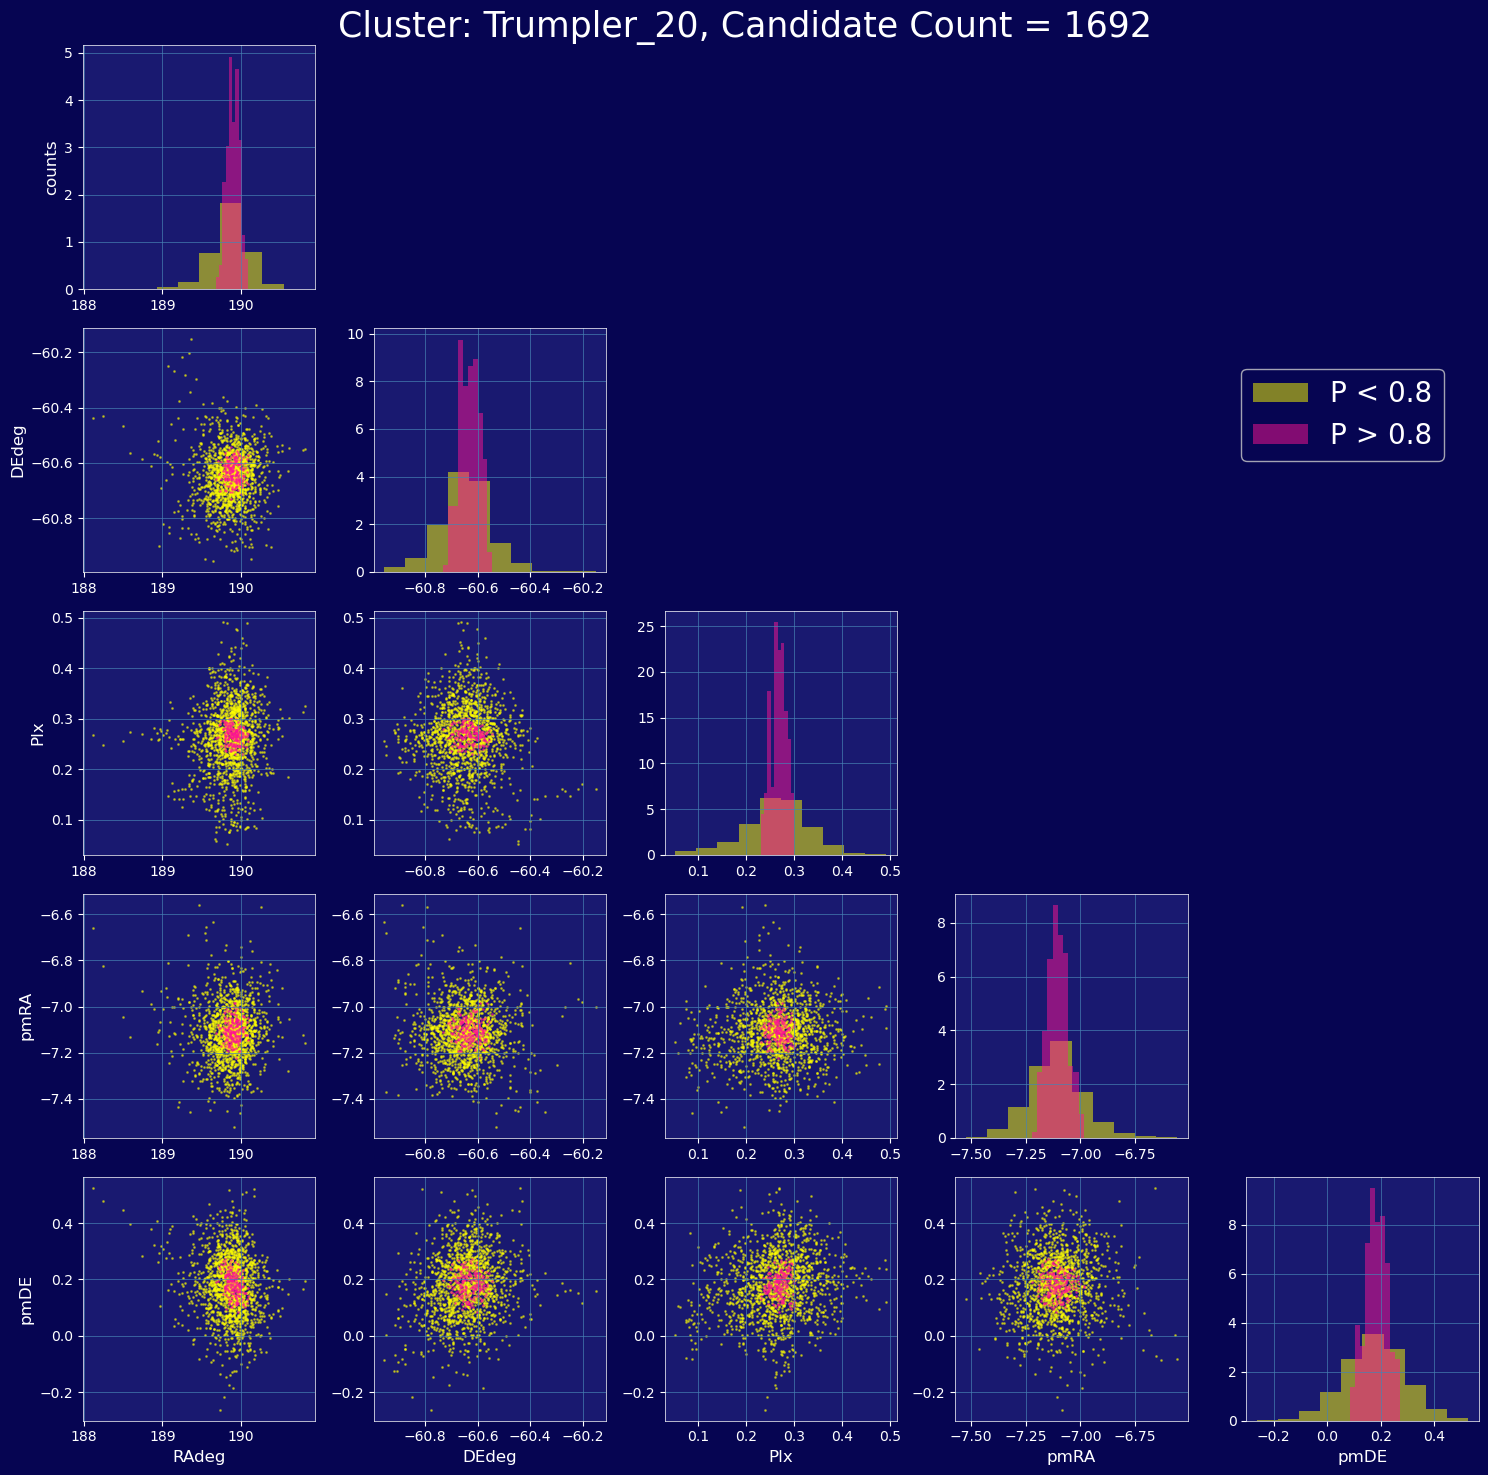

In [19]:
# main df for gt_df = GTp8_cl4stars
# main df for lt_df = LTp8_cl4stars
labels_5param = ['RAdeg', 'DEdeg', 'Plx', 'pmRA', 'pmDE']
cluster_names = ['NGC_6402','NGC_1039','NGC_362','Trumpler_20']

for cluster in cluster_names: 
    cluster_scatter_matrix(cluster, LTp8_cl4stars, GTp8_cl4stars, labels_5param)

For each cluster, answer the following questions, and explain the reasoning for your answer.
For each answer, include one quoted observation (e.g. “the clouds overlap almost entirely in
pmDE”), and one Figure number where that observation is apparent:
* Which pair of dimensions most strongly separates high- and low-Prob stars? **Choose exactly one: RA–Dec, Parallax–pmRA, pmRA–pmDE**
* Which dimension contributes least to separation? **Choose exactly one: RA, Dec, Parallax, pmRA, pmDE**
* Which statement matches best the evidence in your plots?
    1. The algorithm primarily exploits spatial clustering (i.e. in position)
    2. The algorithm primarily exploits kinematic coherence (i.e. in stellar motion)
    3. The separation is weak and likely noise-dominated.

### Cluster NGC_6402: 
i. I would say that parallax-pmDE most strongly separates high- and low-prob stars. I know that the effect is also visible in Parallax-RAdeg and Parallax-DEdeg, but I found it more interesting that the distribution of points with my choice (Plx-PM) appears more asymmetric and spread out (there appears some spatial uniformity in the Plx-RAdeg&DEdeg plots).  
ii. either RAdeg or DEdeg contributes the least to separation
iii. The algorithm primarily exploits kinematic coherence (i.e. stellar motion), as the separation and spreading is more visible in the proper motion plots.

### Cluster NGC_1039: 
i. Parallax-DEdeg seems to separate the two groups the most. 
ii. pmRA seems to contribute the least to separation, which I notice the most in hte pmDE-pmRA plot, where the scatter distribution looks quite spread out and shared. 
iii. The algorithm primarily exploits spatial clustering. 

### Cluster NGC_362: 
i. Parallax-pmDE seems to most strongly separate the groups; there is a noticeable tilt in the scatter plot. I notice that the relative difference in max probability density between the groups for DEdeg's histogram is the largest (~9/2), but the spatial PDFs are so closely overlapped compared to the other three. When looking to see which of the proper motion seemed to be more influential, I compare the proper motion vs. RA/DEC plots (bottom left four) to try to distinguish influence. pmRA-RAdeg & pmRA-DEdeg seem almost reflections of each other, while in the two pmDE plots there is clear contrast in symmetry.  
ii.  RAdeg seem to contribute the least. 
iii. Algorithm primarily exploits kinematic coherence (based on previous answers and big influence of pmDE).

### Trumpler_20: 
i. The separation here feels harder to distinguish. But again, Parallax-pmDE seems to separate the groups the most. However, I also notice that between RAdeg and DEdeg, there is a clear spreading with the declination dependence.
ii. RAdeg seems to contribute the least, as its relevant scatter plots seem consistent regardless of right ascension. 
iii. Both spatial and kinematic aspects seem to be at play here, so I will say the separation is too weak and likely noise-dominated. Especially also because the PDFs between the groups overlap so much compared to other plots. 

#### Self-check: Briefly, answer the following two questions: Could this explanation have been written without looking at any Gaia data? If yes, go back and make sure your answers are backed up with observations from your figures. 

I don't think these explanations could be made without looking at Gaia data, since there is some nuance in my answers.

#### Which observation changes the most between different clusters? 

This feels also hard to answer definitively, as the plots seem to all change a lot between different clusters. One thing I did notice changing was the range of possible values (the x-axis ) in the histograms, specifically with the proper motion plots. At first I though this might just be a question of sample size (because the cluster with the largest number of candidates, NGC_362, had noticeably wider distriutions especially in the proper motion parameters). But then comparing the second highest count cluster Trumpler_20 (count = 1692) and the lowest, NGC_1039 (1095), I cannot infer a relationship between candidate count and the possibility range. For example: for NGC_1039 (c = 1095) RAdeg hist is between 36-44. NGC_6402 (c = 1335)'s range is about 264.2 - 264.8 for the same plot, while NGC_632 (c = 8941)'s is 10-25. This difference is observable also in the proper motion histograms as well, and also does not appear to correspond to sample size (pmDE histogram range for lowest count ~ 3, highest count ~ 5, second highest ~ 0.5) 

I now realize this might have to do with the instrument/observations (things I do not understand about these values), which still does not feel completely intuitive given that these are all absolute measurements being derived from observations made with the same instrument (Gaia). 

----------------------------------------------------------------

### 2. Exploratory Data Analysis and Hypothesis Testing (6pts): We would like to select clusters that are tightly clustered together, to rule out looser associations which will have a wide spatial variance in their parameters due to the range of distances from us.
 To select such clusters, you can use the following lines of code to create a new stars dataframe containing only the higher-probability stars based on a threshold and to create a new clusters dataframe with the star counts and standard deviations in RA and Dec for each cluster: 

In [20]:
p_thres = 0.85 # !! select your threshold here !!
stars_hiprob = stars[stars.Prob > p_thres] # stars.Prob? clarify function
clusters_hiprob = stars_hiprob.groupby(['Name']).size().reset_index(name='count')
clusters_sd_hiprob = stars_hiprob.groupby(['Name']).std(numeric_only=True).reset_index()
clusters_hiprob['sd_RAdeg'] = clusters_sd_hiprob['RAdeg']
clusters_hiprob['sd_DEdeg'] = clusters_sd_hiprob['DEdeg']

clusters_hiprob

,Name,count,sd_RAdeg,sd_DEdeg
0,1636-283,26,0.025858,0.031373
1,ADS_16795,41,5.028249,2.071391
2,AH03_J0748+26.9,23,0.029533,0.024314
3,ASCC_100,67,0.786173,0.930178
4,ASCC_101,132,0.445961,0.751172
...,...,...,...,...
7162,vdBergh_152,25,0.863601,0.201857
7163,vdBergh_80,65,0.213430,0.171727
7164,vdBergh_83,92,0.283638,0.200000
7165,vdBergh_85,105,0.107164,0.077127


Now use the new `clusters_hiprob` dataframe to make a new cluster sample containing only
clusters with > 200 stars and standard deviations of RA and Dec < 0.1° (to constrain the cluster size). An interesting question is whether there is any spatial (RA and Dec) variation of the other astrometric and photometric parameters in each cluster.

In [21]:
cl_hiprob_gt200 = clusters_hiprob[clusters_hiprob['count']>200].sort_values('count', ascending = False)
print('cluster high probability greater than 200:')
cl_hiprob_gt200

cluster high probability greater than 200:


,Name,count,sd_RAdeg,sd_DEdeg
4638,NGC_5139,3167,0.229304,0.118912
5785,Theia_3623,3086,0.556936,0.293170
3864,HSC_655,3047,0.355850,0.189797
5921,Theia_6046,2925,0.841412,1.159279
4783,NGC_6656,1767,0.067718,0.069157
...,...,...,...,...
4580,NGC_2632,203,0.504105,0.491808
6872,UBC_600,203,0.573937,0.209768
6059,Trumpler_25,202,0.042934,0.035774
6124,UBC_106,202,0.058114,0.053156


In [22]:
clhp_gt200_stdltp1 = cl_hiprob_gt200[(cl_hiprob_gt200['sd_DEdeg'] < 0.1) & (cl_hiprob_gt200['sd_RAdeg'] < 0.1)]
print('cluster high probability greater than 200 and standard deviations less than 0.1:')
clhp_gt200_stdltp1 

cluster high probability greater than 200 and standard deviations less than 0.1:


,Name,count,sd_RAdeg,sd_DEdeg
4783,NGC_6656,1767,0.067718,0.069157
4678,NGC_6121,1504,0.046694,0.041750
4731,NGC_6397,1494,0.081423,0.046758
4691,NGC_6205,806,0.063549,0.041828
4600,NGC_3201,747,0.056409,0.037390
4808,NGC_6809,709,0.043761,0.038902
4694,NGC_6218,658,0.032725,0.030468
4664,NGC_5904,580,0.038929,0.035678
4718,NGC_6341,467,0.044820,0.035705
4758,NGC_6544,416,0.041062,0.041286


In [23]:
# doing number selection here, immediately to report in cell below
random_cluster = np.random.choice(clhp_gt200_stdltp1['Name'], size=1)
print(random_cluster)

['NGC_6402']


### NOTE: my randomly-selected cluster is HSC_186.
(Again, I did not know about the "seed" method, and chose this cluster.) 

a. Randomly select one filtered cluster, note down its name and the random seed you used in the notebook. Before making any new plots, based on your previous analysis, answer:

* Will the parallax distribution vary with RA?
* Will proper motion dispersion increase, decrease or stay constant with RA and Dec?

Justify each choice in one sentence, noting down which previous figure/result you base your prediction on. To be clear: incorrect predictions will not be penalized, you will be graded on the coherence of your argument, not on the correctness ofE the prediction.

**1. Will the parallax distribution vary with RA?**

I do not think the parallax distribution will vary with RA, both from an astrophysics standpoint and also graphically. Graphically, the third scatter plot matrix about NGC_362 (the largest number of candidates) made me realize that most values in principle should not really vary along RA and DEC measurements for a proper cluster, in part because it is the same observation but more so (physically) because if it really is a cluster, the distance from each star should not vary so drastically so as to be observable in a plot like this. Dispersion should only be due to instrumental/measurement noise. Because I have now filtered to only include data of very tightly-clustered systems, parallax should not vary. 

**2. Will proper motion dispersion increase, decrease, or stay constant with RA and DEC?**

Now looking back, I am better recognizing the relationship between the tightness of clustering and the dispersion of proper motion; based on the fact that Trumpler_20 (4th cluster plot) was the most clustered at least in Declination (y axis of DEdeg vs. RAdeg), and the pmDE dispersion was minimized (range of ~0.5, bottom right histogram), I predict that the proper motion dispersion, compared to the previous plots, should decrease given that standard deviations of RA and Dec have been minimized; but it should remain constant in the plots I now produce. 

#### Now, will be: 
Splitting into two subsamples in `RA`: 
1. $RA \gt \langle RA \rangle$
2. $RA \lt \langle RA \rangle$

Splitting into two subsamples in `Dec`: 
1. $Dec \gt \langle Dec \rangle$
2. $Dec \lt \langle Dec \rangle$


In [24]:
my_cluster = stars[stars['Name'] == 'HSC_186']
my_cluster

,Name,ID,GaiaDR3,inrt,Prob,RAdeg,e_RAdeg,DEdeg,e_DEdeg,GLON,...,o_RVd,GRVSmag,e_GRVSmag,o_GRVSmag,Vbroad,e_Vbroad,o_Vbroad,VarFlag,NSS,RVS
215826,HSC_186,1932,4098039472071049088,1,1.000000,275.419474,0.118330,-15.796145,0.112522,15.527798,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
215827,HSC_186,1932,4098039437711360896,1,0.990168,275.438064,0.173737,-15.785955,0.168054,15.545203,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
215828,HSC_186,1932,4098039403351576064,1,0.992957,275.427780,0.180885,-15.795391,0.173335,15.532221,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
215829,HSC_186,1932,4098039373298532608,1,1.000000,275.410186,0.084593,-15.799929,0.078863,15.520256,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
215830,HSC_186,1932,4098039334632033536,1,1.000000,275.385595,0.038676,-15.808947,0.036627,15.501169,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216067,HSC_186,1932,4098034459839447040,0,0.970536,275.250431,0.111786,-15.879223,0.104260,15.377961,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
216068,HSC_186,1932,4098033665280070400,0,1.000000,275.377994,0.034288,-15.811709,0.033131,15.495291,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
216069,HSC_186,1932,4098033630915412096,0,0.948903,275.368583,0.073905,-15.818396,0.081616,15.485130,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
216070,HSC_186,1932,4098033596555659776,0,0.953972,275.332679,0.159167,-15.819397,0.145345,15.467993,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0


Personal question: would I have gotten the same table if I'd filtered using the `e_RAdeg` and `e_DEdeg` values instead of using standard deviation? 

Average RAdeg: 275.4213627192683
Average DEdeg: -15.823392489105691


Text(0.5, 1.0, 'Dec Distribution')

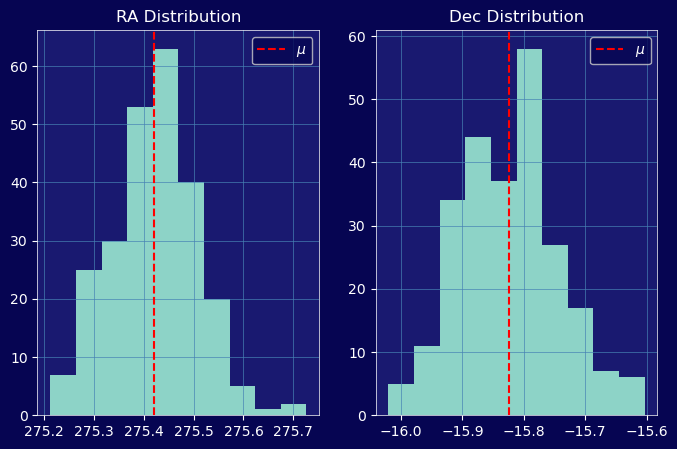

In [25]:
print(f"Average RAdeg: {np.mean(my_cluster['RAdeg'])}")
print(f"Average DEdeg: {np.mean(my_cluster['DEdeg'])}")

# just out of curiosity
fig, ax = plt.subplots(1,2, figsize = (8,5))

ax[0].hist(my_cluster['RAdeg'])
ax[0].axvline(np.mean(my_cluster['RAdeg']), ls = 'dashed', color = 'red', label = r'$\mu$')
ax[0].legend()
ax[0].set_title('RA Distribution')

ax[1].hist(my_cluster['DEdeg'])
ax[1].axvline(np.mean(my_cluster['DEdeg']), ls = 'dashed', color = 'red', label = r'$\mu$')
ax[1].legend()
ax[1].set_title('Dec Distribution')


In [26]:
RA_ltmean = my_cluster[my_cluster['RAdeg'] < np.mean(my_cluster['RAdeg'])]
RA_gtmean = my_cluster[my_cluster['RAdeg'] > np.mean(my_cluster['RAdeg'])]
Dec_ltmean = my_cluster[my_cluster['DEdeg'] < np.mean(my_cluster['DEdeg'])]
Dec_gtmean = my_cluster[my_cluster['DEdeg'] > np.mean(my_cluster['DEdeg'])]

RAs = [RA_ltmean, RA_gtmean]
Decs = [Dec_ltmean, Dec_gtmean]

* show the histograms of the following parameters for each of the 2 subsamples: `Plx`, `pmRA`, `pmDE`, `Gmag` and `BP-RP`. 

In [230]:
def plotter_2b_w_genmean(spatial_var, var_name, cluster): 

    fig, ax = plt.subplots(5, 2, figsize = (10,18))

    # ---- parallax ----
    # less than mean 
    ax[0,0].hist(spatial_var[0]['Plx'], density = True, bins = 25, color = 'cyan', label = f'${var_name} < \\langle {var_name} \\rangle $')
    ax[0,0].axvline(np.mean(spatial_var[0]['Plx']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset}}$ = {np.mean(spatial_var[0]["Plx"]):.3f}')
    ax[0,0].axvline(np.mean(cluster["Plx"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["Plx"]):.3f}')
    ax[0,0].legend()
    ax[0,0].set_title(f'Parallax below mean {var_name}')
    # greater than mean
    ax[0,1].hist(spatial_var[1]['Plx'], density = True, bins = 25, color = 'violet', label = f'${var_name} > \\langle {var_name} \\rangle $')
    ax[0,1].axvline(np.mean(spatial_var[1]['Plx']), color = 'gold', ls = 'dashed', label = f'$\mu$ = {np.mean(spatial_var[1]["Plx"]):.3f}')
    ax[0,1].axvline(np.mean(cluster["Plx"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["Plx"]):.3f}')
    ax[0,1].legend()
    ax[0,1].set_title(f'Parallax above mean {var_name}')

    # --- proper motion RA ---
    # less than mean 
    ax[1,0].hist(spatial_var[0]['pmRA'], density = True, bins = 25, color = 'cyan', label = f'${var_name} < \\langle {var_name} \\rangle $')
    ax[1,0].axvline(np.mean(spatial_var[0]['pmRA']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset}}$ = {np.mean(spatial_var[0]["pmRA"]):.3f}')
    ax[1,0].axvline(np.mean(cluster["pmRA"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["pmRA"]):.3f}')    
    ax[1,0].legend()
    ax[1,0].set_title(f'pmRA below mean {var_name}')
    # greater than mean 
    ax[1,1].hist(spatial_var[1]['pmRA'], density = True, bins = 25, color = 'violet', label = f'${var_name} > \\langle {var_name} \\rangle $')
    ax[1,1].axvline(np.mean(spatial_var[1]['pmRA']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset}}$ = {np.mean(spatial_var[1]["pmRA"]):.3f}')
    ax[1,1].axvline(np.mean(cluster["pmRA"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["pmRA"]):.3f}')    
    ax[1,1].legend()
    ax[1,1].set_title(f'pmRA above mean {var_name}')

    # --- proper motion Dec ---
    # less than mean 
    ax[2,0].hist(spatial_var[0]['pmDE'], density = True, bins = 25, color = 'cyan', label = f'${var_name} < \\langle {var_name} \\rangle $')
    ax[2,0].axvline(np.mean(spatial_var[0]['pmDE']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset}}$ = {np.mean(spatial_var[0]["pmDE"]):.3f}')
    ax[2,0].axvline(np.mean(cluster["pmDE"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["pmDE"]):.3f}')    
    ax[2,0].legend()
    ax[2,0].set_title(f'pmDE below mean {var_name}')
    # greater than mean
    ax[2,1].hist(spatial_var[1]['pmDE'], density = True, bins = 25, color = 'violet', label = f'${var_name} > \\langle {var_name} \\rangle $')
    ax[2,1].axvline(np.mean(spatial_var[1]['pmDE']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset}}$ = {np.mean(spatial_var[1]["pmDE"]):.3f}')
    ax[2,1].axvline(np.mean(cluster["pmDE"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["pmDE"]):.3f}')    
    ax[2,1].legend()
    ax[2,1].set_title(f'pmDE above mean {var_name}')

    # --- G-Magnitude ---
    # less than mean
    ax[3,0].hist(spatial_var[0]['Gmag'], density = True, bins = 25, color = 'cyan', label = f'${var_name} < \\langle {var_name} \\rangle $')
    ax[3,0].axvline(np.mean(spatial_var[0]['Gmag']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset}}$ = {np.mean(spatial_var[0]["Gmag"]):.3f}')
    ax[3,0].axvline(np.mean(cluster["Gmag"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["Gmag"]):.3f}')    
    ax[3,0].legend()
    ax[3,0].set_title(f'Gmag below mean {var_name}')
    # greater than mean
    ax[3,1].hist(spatial_var[1]['Gmag'], density = True, bins = 25, color = 'violet', label = f'${var_name} > \\langle {var_name} \\rangle $')
    ax[3,1].axvline(np.mean(spatial_var[1]['Gmag']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset}}$ = {np.mean(spatial_var[1]["Gmag"]):.3f}')
    ax[3,1].axvline(np.mean(cluster["Gmag"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["Gmag"]):.3f}')    
    ax[3,1].legend()
    ax[3,1].set_title(f'Gmag above mean {var_name}')

    # --- BP-RP (photometric?) ---
    # less than mean 
    ax[4,0].hist(spatial_var[0]['BP-RP'], density = True, bins = 25, color = 'cyan', label = f'${var_name} < \\langle {var_name} \\rangle $')
    ax[4,0].axvline(np.mean(spatial_var[0]['BP-RP']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset}}$ = {np.mean(spatial_var[0]["BP-RP"]):.3f}')
    ax[4,0].axvline(np.mean(cluster["BP-RP"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["BP-RP"]):.3f}')    
    ax[4,0].legend()
    ax[4,0].set_title(f'BP-RP below mean {var_name}')
    # greater than mean
    ax[4,1].hist(spatial_var[1]['BP-RP'], density = True, bins = 25, color = 'violet', label = f'${var_name} > \\langle {var_name} \\rangle $')
    ax[4,1].axvline(np.mean(spatial_var[1]['BP-RP']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset}}$ = {np.mean(spatial_var[1]["BP-RP"]):.3f}')
    ax[4,1].axvline(np.mean(cluster["BP-RP"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["BP-RP"]):.3f}')        
    ax[4,1].legend()
    ax[4,1].set_title(f'BP-RP above mean {var_name}')

    plt.tight_layout()

    


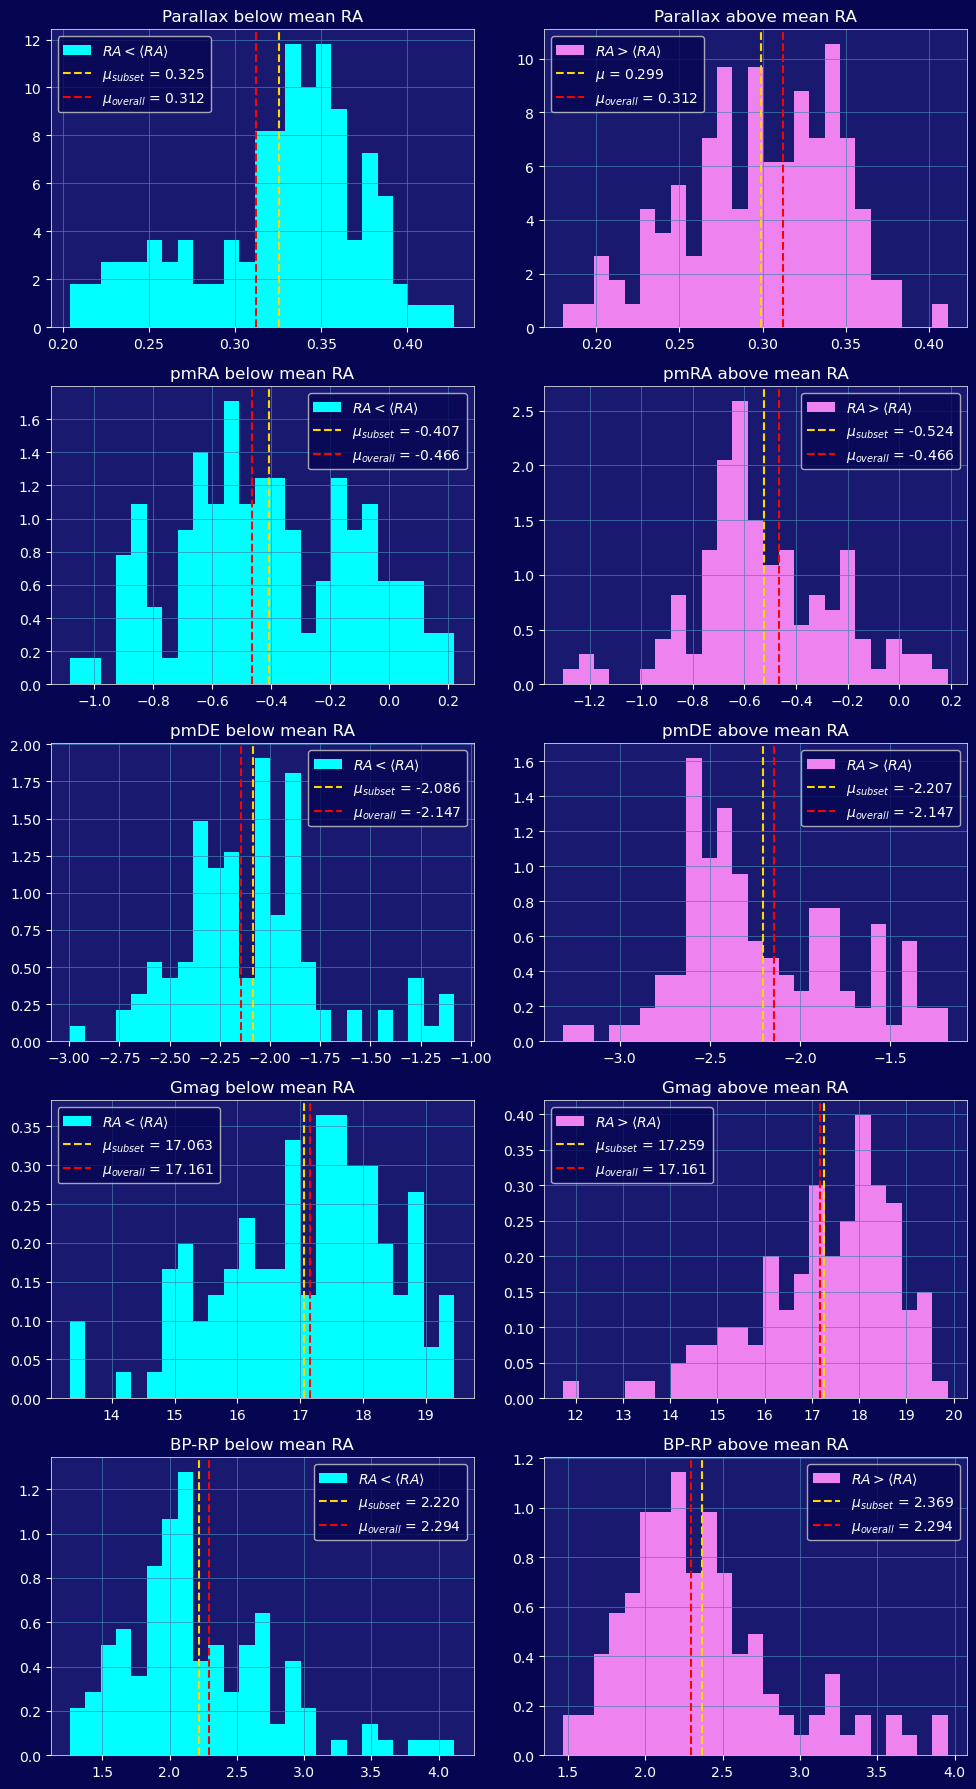

In [231]:
plotter_2b_w_genmean(RAs, var_name = 'RA', cluster = my_cluster)

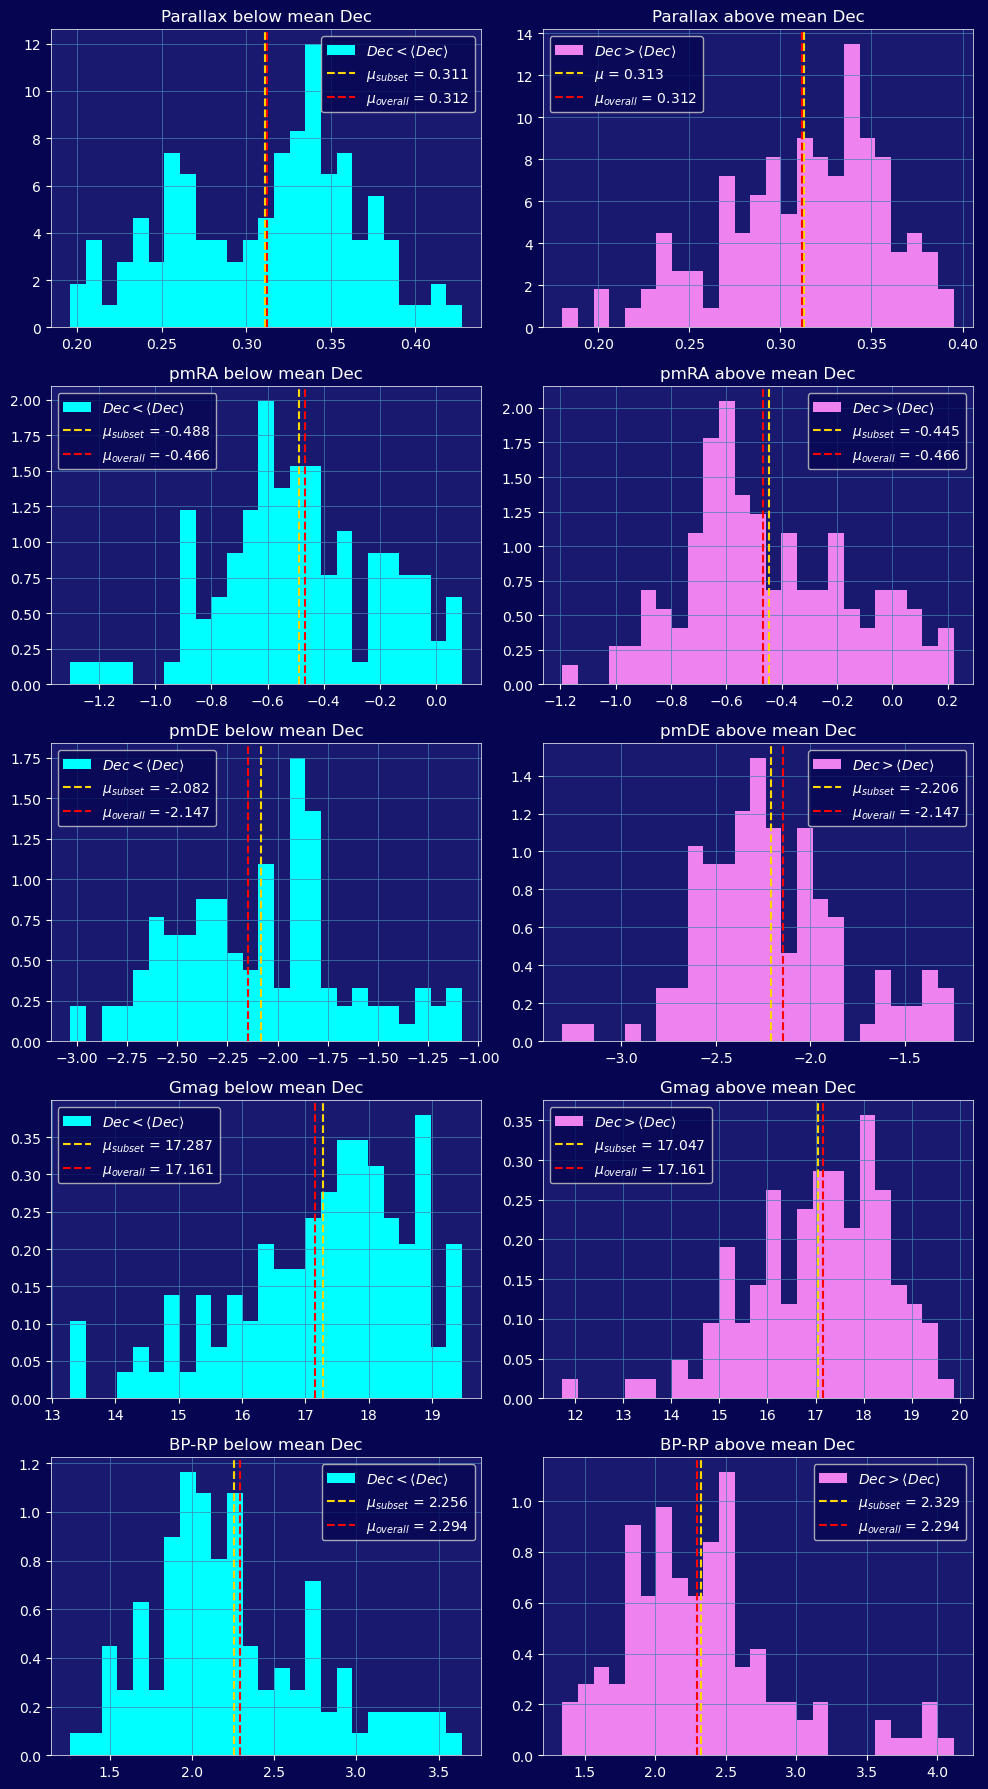

In [232]:
plotter_2b_w_genmean(Decs, var_name = 'Dec', cluster = my_cluster)

In [40]:
def plotter_2b_genmean_overplot_hist(spatial_var, var_name, cluster): 

    fig, ax = plt.subplots(5, 1, figsize = (5,15))

    # ---- parallax ----
    # less than mean hist
    ax[0].hist(spatial_var[0]['Plx'], density = True, bins = 25, color = 'cyan', alpha = 0.6, label = f'${var_name} < \\langle {var_name} \\rangle $')
    #ax[0,0].axvline(np.mean(spatial_var[0]['Plx']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset}}$ = {np.mean(spatial_var[0]["Plx"]):.3f}')
    # greater than mean hist 
    ax[0].hist(spatial_var[1]['Plx'], density = True, bins = 25, color = 'violet', alpha = 0.6, label = f'${var_name} > \\langle {var_name} \\rangle $')
    # overall mean
    ax[0].axvline(np.mean(cluster["Plx"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["Plx"]):.3f}')
    ax[0].legend()
    ax[0].set_title(f'Parallaxes overplotted for {var_name}')
    
    # --- proper motion RA ---
    # less than mean hist
    ax[1].hist(spatial_var[0]['pmRA'], density = True, bins = 25, color = 'cyan', alpha = 0.6, label = f'${var_name} < \\langle {var_name} \\rangle $')
    #ax[1].axvline(np.mean(spatial_var[0]['pmRA']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset}}$ = {np.mean(spatial_var[0]["pmRA"]):.3f}')
    # greater than mean hist
    ax[1].hist(spatial_var[1]['pmRA'], density = True, bins = 25, color = 'violet', alpha = 0.6, label = f'${var_name} > \\langle {var_name} \\rangle $')
    # overall mean 
    ax[1].axvline(np.mean(cluster["pmRA"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["pmRA"]):.3f}')    
    ax[1].legend()
    ax[1].set_title(f'pmRA overplotted for {var_name}')

    # --- proper motion Dec ---
    # less than mean hist
    ax[2].hist(spatial_var[0]['pmDE'], density = True, bins = 25, color = 'cyan', alpha = 0.6, label = f'${var_name} < \\langle {var_name} \\rangle $')
    #ax[2,0].axvline(np.mean(spatial_var[0]['pmDE']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset}}$ = {np.mean(spatial_var[0]["pmDE"]):.3f}')
    # greater than mean hist
    ax[2].hist(spatial_var[1]['pmDE'], density = True, bins = 25, color = 'violet', alpha = 0.6, label = f'${var_name} > \\langle {var_name} \\rangle $')
    # overall mean
    ax[2].axvline(np.mean(cluster["pmDE"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["pmDE"]):.3f}')    
    ax[2].legend()
    ax[2].set_title(f'pmDE overplotted for {var_name}')

    # --- G-Magnitude ---
    # less than mean
    ax[3].hist(spatial_var[0]['Gmag'], density = True, bins = 25, color = 'cyan', alpha = 0.6, label = f'${var_name} < \\langle {var_name} \\rangle $')
    #ax[3,0].axvline(np.mean(spatial_var[0]['Gmag']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset}}$ = {np.mean(spatial_var[0]["Gmag"]):.3f}')
    #greater than mean hist
    ax[3].hist(spatial_var[1]['Gmag'], density = True, bins = 25, color = 'violet', alpha = 0.6, label = f'${var_name} > \\langle {var_name} \\rangle $')
    # overall mean
    ax[3].axvline(np.mean(cluster["Gmag"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["Gmag"]):.3f}')    
    ax[3].legend()
    ax[3].set_title(f'Gmag above mean {var_name}')

    # --- BP-RP (photometric?) ---
    # less than mean 
    ax[4].hist(spatial_var[0]['BP-RP'], density = True, bins = 25, color = 'cyan', alpha = 0.6, label = f'${var_name} < \\langle {var_name} \\rangle $')
    #ax[4,0].axvline(np.mean(spatial_var[0]['BP-RP']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset}}$ = {np.mean(spatial_var[0]["BP-RP"]):.3f}')
    # greater than mean hist
    ax[4].hist(spatial_var[1]['BP-RP'], density = True, bins = 25, color = 'violet', alpha = 0.6, label = f'${var_name} > \\langle {var_name} \\rangle $')
    # overall mean 
    ax[4].axvline(np.mean(cluster["BP-RP"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["BP-RP"]):.3f}')        
    ax[4].legend()
    ax[4].set_title(f'BP-RP overplotted for {var_name}')

    plt.tight_layout()

    


If I had more time, it would have been good to also have this as a subplot with histograms overplotted for RA and Dec just next to each other in one giant subplot.

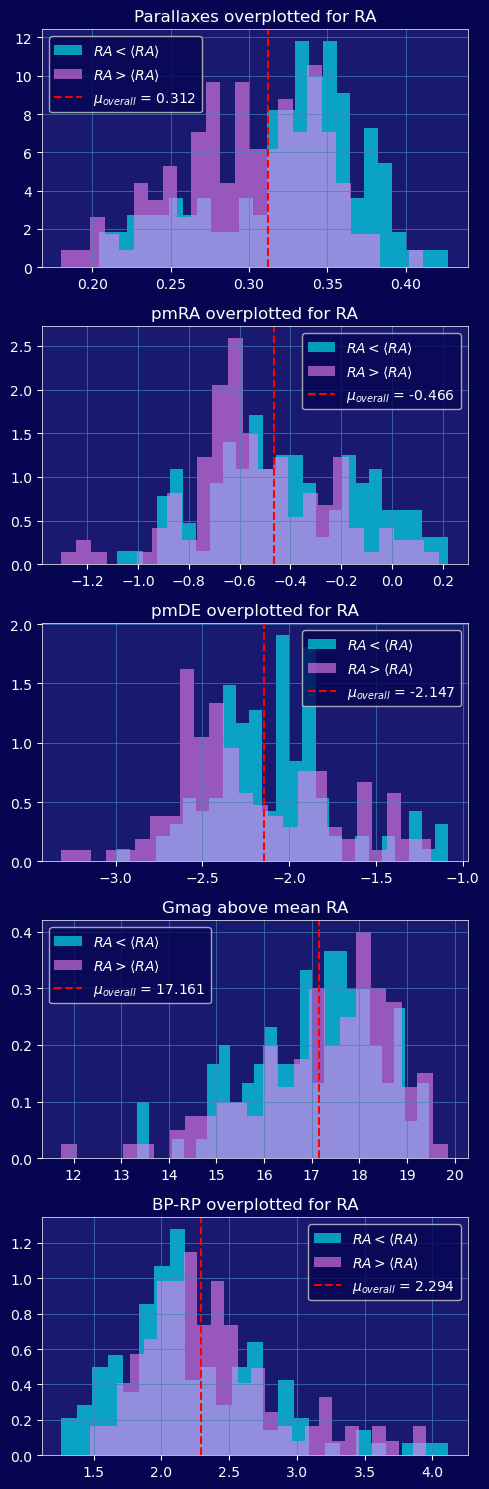

In [41]:
plotter_2b_genmean_overplot_hist(RAs, 'RA', cluster = my_cluster)

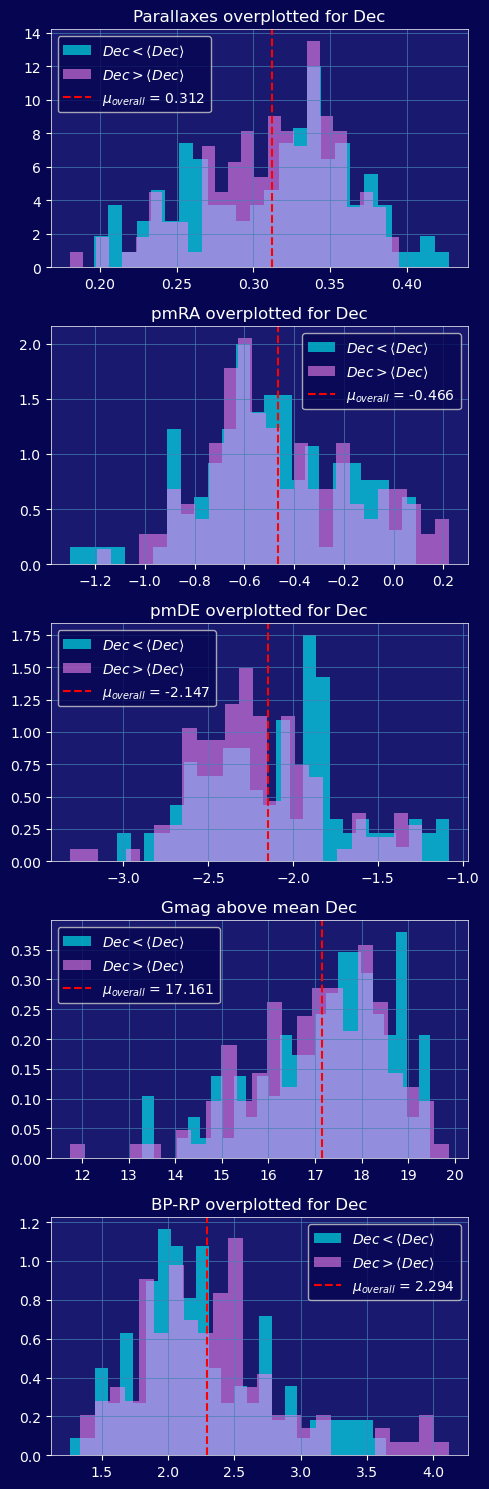

In [42]:
plotter_2b_genmean_overplot_hist(Decs, 'Dec', cluster = my_cluster)

In [88]:
def overplot_hist_2b_overplot_w_all_means(spatial_var, var_name, cluster): 

    fig, ax = plt.subplots(5, 1, figsize = (10,18))

    # ---- parallax ----
    # less than mean 
    ax[0].hist(spatial_var[0]['Plx'], density = True, bins = 25, color = 'cyan', label = f'${var_name} < \\langle {var_name} \\rangle $')
    # greater than mean
    ax[0].hist(spatial_var[1]['Plx'], density = True, bins = 25, alpha = 0.8, color = 'violet', label = f'${var_name} > \\langle {var_name} \\rangle $')
    # avgs & plot  
    ax[0].axvline(np.mean(spatial_var[0]['Plx']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset,low}}$ = {np.mean(spatial_var[0]["Plx"]):.3f}')
    ax[0].axvline(np.mean(spatial_var[1]['Plx']), color = 'deepskyblue', ls = 'dashed', label = f'$\mu_{{subset,high}}$ = {np.mean(spatial_var[1]["Plx"]):.3f}')
    ax[0].axvline(np.mean(cluster["Plx"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["Plx"]):.3f}')
    ax[0].legend()
    ax[0].set_title('Parallax')

    # --- proper motion RA ---
    # less than mean 
    ax[1].hist(spatial_var[0]['pmRA'], density = True, bins = 25, color = 'cyan', label = f'${var_name} < \\langle {var_name} \\rangle $')
    # greater than mean 
    ax[1].hist(spatial_var[1]['pmRA'], density = True, bins = 25, alpha = 0.8, color = 'violet', label = f'${var_name} > \\langle {var_name} \\rangle $')
    # avgs and plot
    ax[1].axvline(np.mean(spatial_var[0]['pmRA']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset,low}}$ = {np.mean(spatial_var[0]["pmRA"]):.3f}') 
    ax[1].axvline(np.mean(spatial_var[1]['pmRA']), color = 'deepskyblue', ls = 'dashed', label = f'$\mu_{{subset,high}}$ = {np.mean(spatial_var[1]["pmRA"]):.3f}')
    ax[1].axvline(np.mean(cluster["pmRA"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["pmRA"]):.3f}') 
    ax[1].legend()
    ax[1].set_title('pmRA')

    # --- proper motion Dec ---
    # less than mean 
    ax[2].hist(spatial_var[0]['pmDE'], density = True, bins = 25, color = 'cyan', label = f'${var_name} < \\langle {var_name} \\rangle $')
    # greater than mean
    ax[2].hist(spatial_var[1]['pmDE'], density = True, bins = 25, alpha = 0.8, color = 'violet', label = f'${var_name} > \\langle {var_name} \\rangle $')
    # greater than mean
    ax[2].axvline(np.mean(spatial_var[0]['pmDE']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset,low}}$ = {np.mean(spatial_var[0]["pmDE"]):.3f}')
    ax[2].axvline(np.mean(spatial_var[1]['pmDE']), color = 'deepskyblue', ls = 'dashed', label = f'$\mu_{{subset,high}}$ = {np.mean(spatial_var[1]["pmDE"]):.3f}')
    ax[2].axvline(np.mean(cluster["pmDE"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["pmDE"]):.3f}')    
    ax[2].legend()
    ax[2].set_title('pmDE')

    # --- G-Magnitude ---
    # less than mean
    ax[3].hist(spatial_var[0]['Gmag'], density = True, bins = 25, color = 'cyan', label = f'${var_name} < \\langle {var_name} \\rangle $')
    # greater than mean
    ax[3].hist(spatial_var[1]['Gmag'], density = True, bins = 25, alpha = 0.8, color = 'violet', label = f'${var_name} > \\langle {var_name} \\rangle $')
    # avgs & plot
    ax[3].axvline(np.mean(spatial_var[0]['Gmag']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset,low}}$ = {np.mean(spatial_var[0]["Gmag"]):.3f}')   
    ax[3].axvline(np.mean(spatial_var[1]['Gmag']), color = 'deepskyblue', ls = 'dashed', label = f'$\mu_{{subset,high}}$ = {np.mean(spatial_var[1]["Gmag"]):.3f}')
    ax[3].axvline(np.mean(cluster["Gmag"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["Gmag"]):.3f}')    
    ax[3].legend()
    ax[3].set_title('Gmag')

    # --- BP-RP (photometric?) ---
    # less than mean 
    ax[4].hist(spatial_var[0]['BP-RP'], density = True, bins = 25, color = 'cyan', label = f'${var_name} < \\langle {var_name} \\rangle $')
    # greater than mean
    ax[4].hist(spatial_var[1]['BP-RP'], density = True, bins = 25, alpha = 0.8, color = 'violet', label = f'${var_name} > \\langle {var_name} \\rangle $')
    # avgs & plot
    ax[4].axvline(np.mean(spatial_var[0]['BP-RP']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset,low}}$ = {np.mean(spatial_var[0]["BP-RP"]):.3f}') 
    ax[4].axvline(np.mean(spatial_var[1]['BP-RP']), color = 'deepskyblue', ls = 'dashed', label = f'$\mu_{{subset,high}}$ = {np.mean(spatial_var[1]["BP-RP"]):.3f}')
    ax[4].axvline(np.mean(cluster["BP-RP"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["BP-RP"]):.3f}')        
    ax[4].legend()
    ax[4].set_title('BP-RP')

    plt.tight_layout()

    


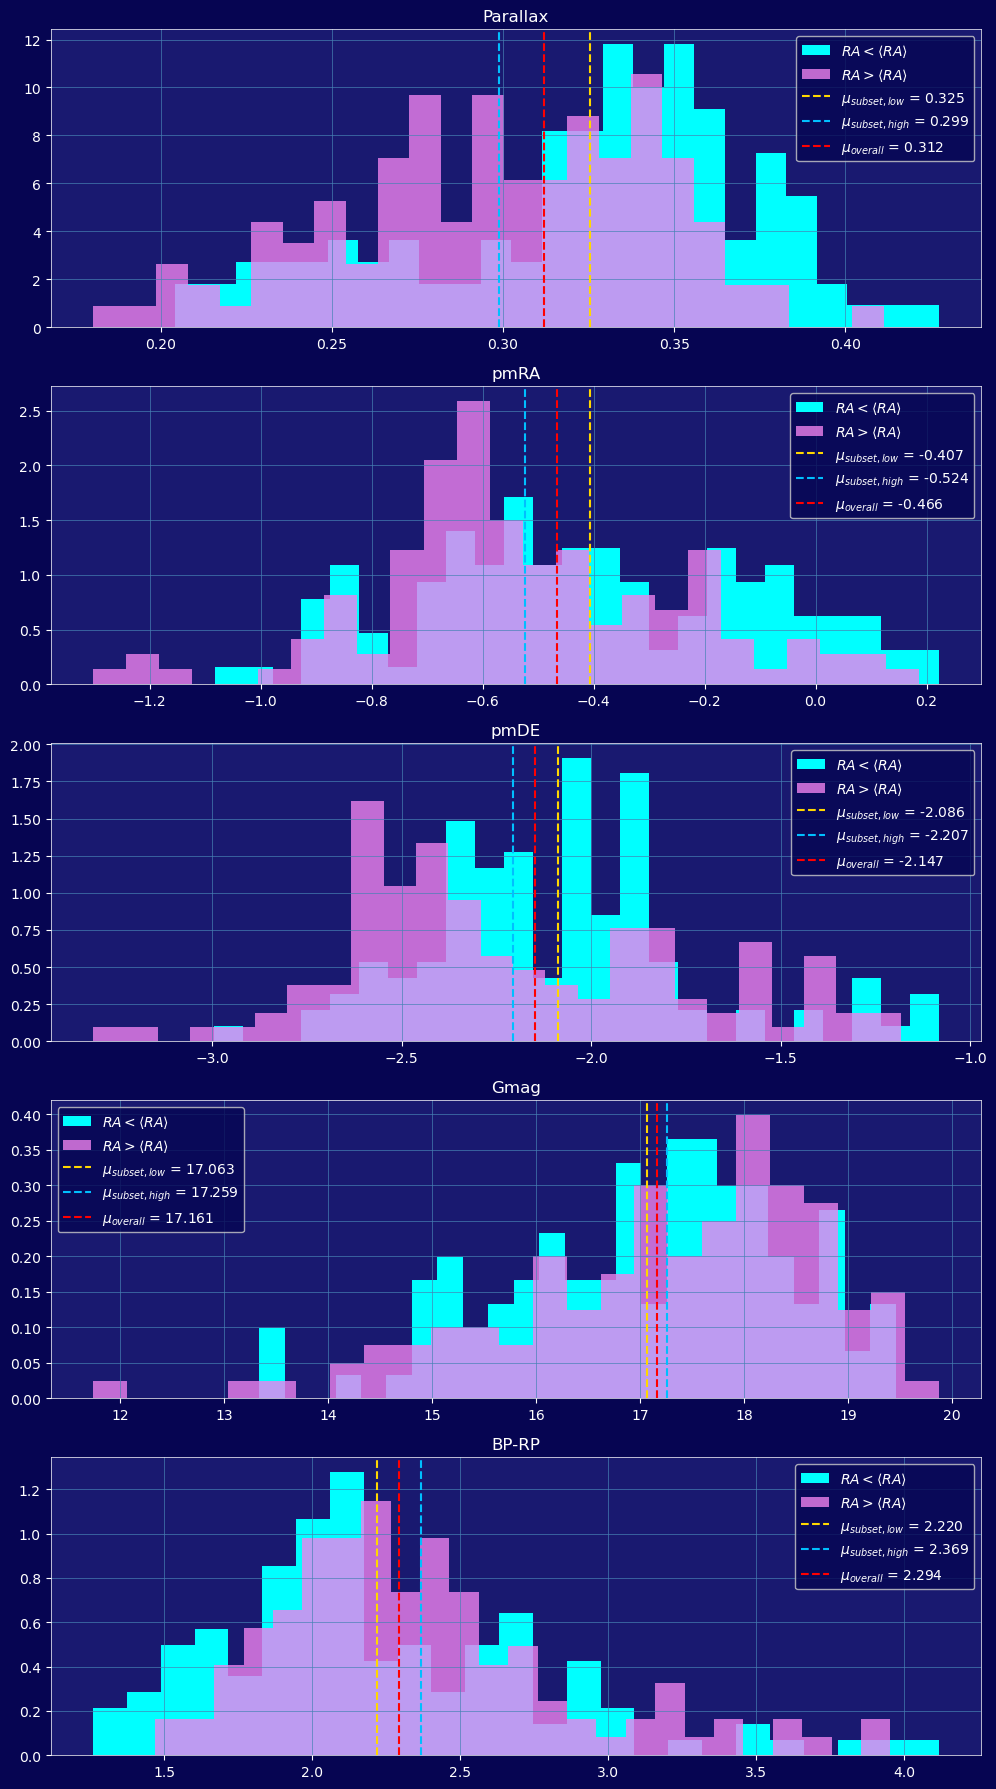

In [89]:
overplot_hist_2b_overplot_w_all_means(RAs, 'RA', my_cluster)

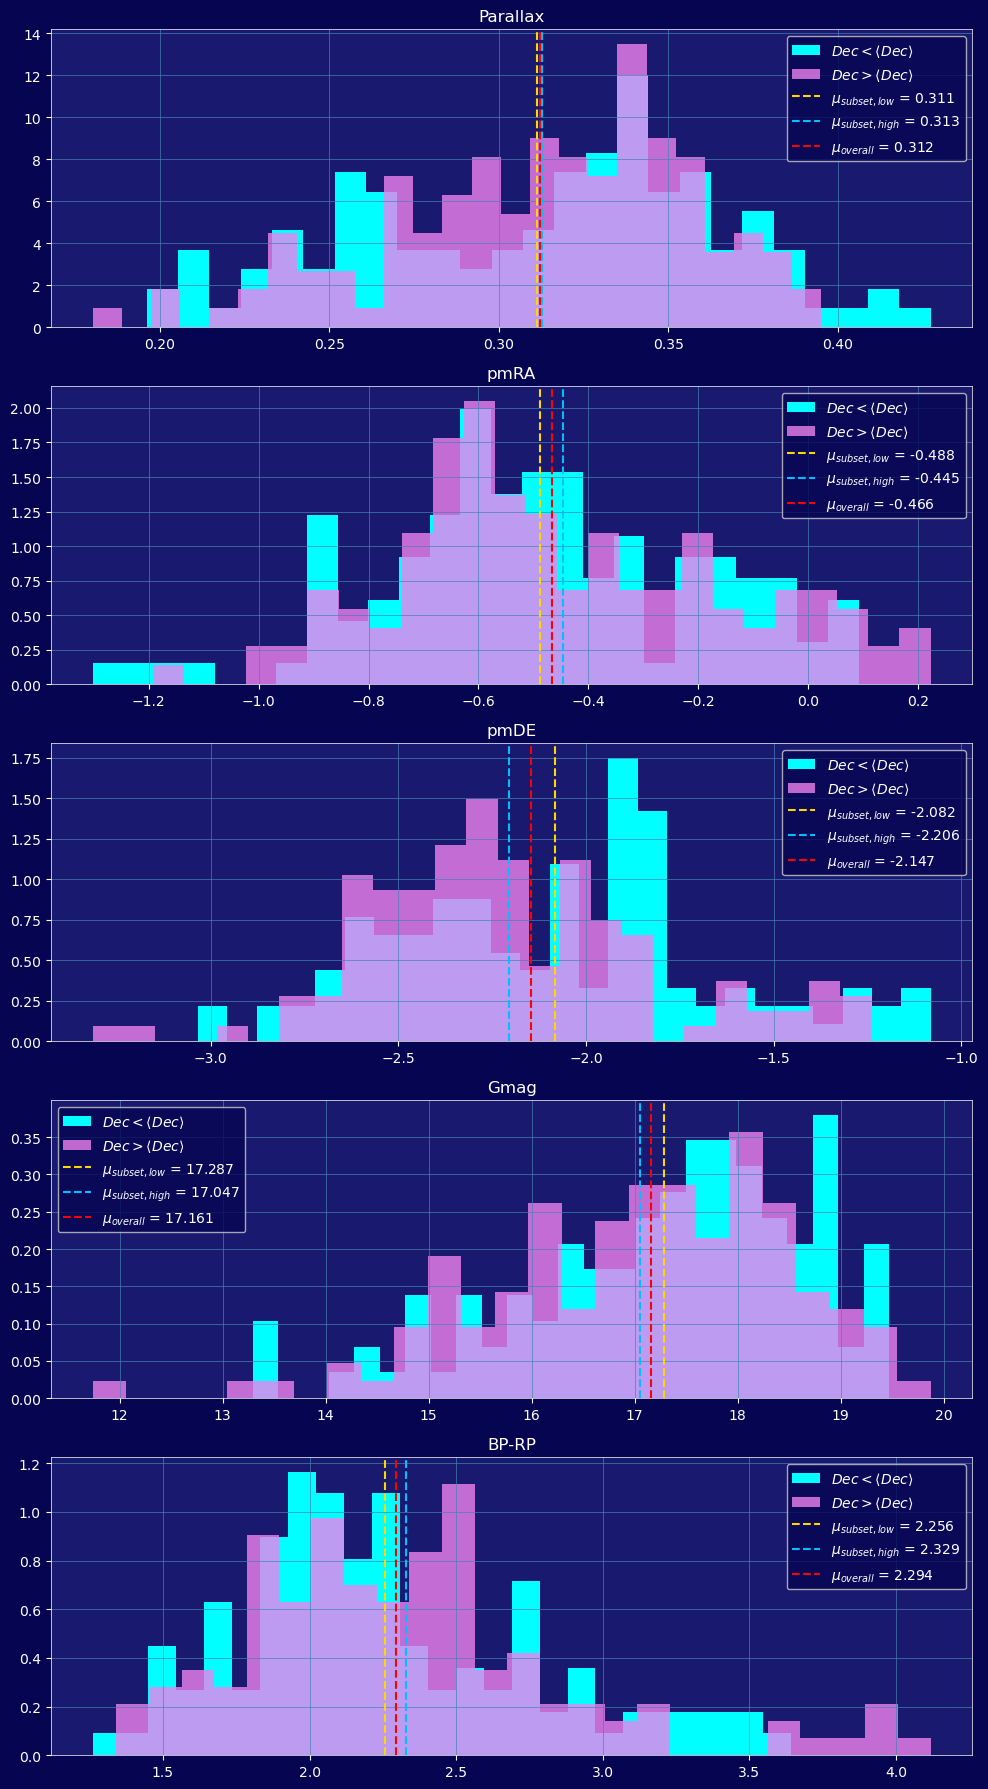

In [90]:
overplot_hist_2b_overplot_w_all_means(Decs, 'Dec', my_cluster)

#### Okay now just curious and want to look at the cluster itself. 

Text(0.5, 1.0, 'Cluster HSC_186')

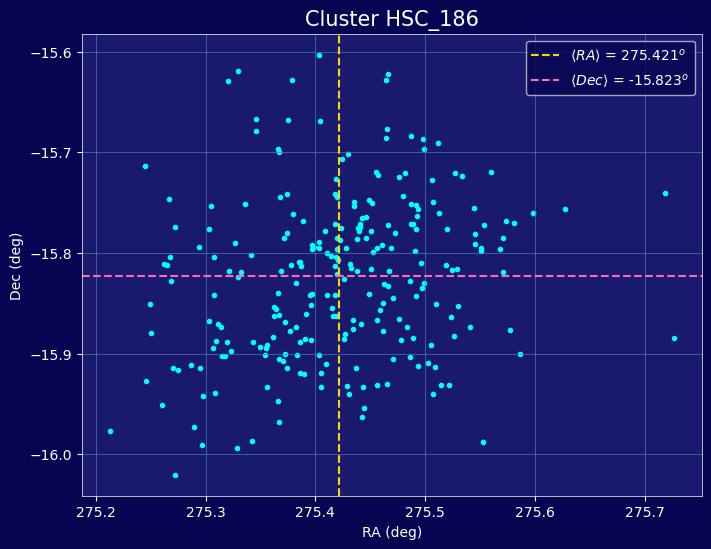

In [91]:
plt.figure(figsize = (8,6))
plt.scatter(my_cluster['RAdeg'], my_cluster['DEdeg'], color = 'cyan', marker='.')
plt.xlabel('RA (deg)')
plt.ylabel('Dec (deg)')
plt.axvline(np.mean(my_cluster['RAdeg']), ls = 'dashed', color = 'gold', label = f'$\langle RA \\rangle$ = {np.mean(my_cluster["RAdeg"]):.3f}$^o$')
plt.axhline(np.mean(my_cluster['DEdeg']), ls = 'dashed', color = 'hotpink', label = f'$\langle Dec \\rangle$ = {np.mean(my_cluster["DEdeg"]):.3f}$^o$')
plt.legend()
plt.title('Cluster HSC_186', fontsize = 15)

***Did your predictions agree with the data?***

* For parallax: Sort of agrees. I predicted that parallax should not vary with RA and Dec; for Dec, the parallax means of the subsets varied from the overall mean by 0.001 (0.1%), which does not seem that significant. However for RA, parallax does indeed vary significantly, with an absolute difference in subset means $= |0.325 - 0.299| = 0.026$, an order of magnitude greater than the Declination difference. However these subset means still only vary from the overall mean by 1%, which seems non-negligible but not catastrophic.


* For proper motion: I predicted that the proper motion dispersion should be constant relative to RA and Dec for these plots, but now see that this doesn't make sense, as proper motion dispersion can depend on different parameters, for example in the plot above, the cluster I'm investigating itself is asymmetric around its mean RA and Dec, so its proper motion, for example if the cluster is rotating, should vary across the spatial grid. This is also evident in my histograms of proper motion, which show that it does indeed vary with RA and Dec. 

#### ***c.** Use hypothesis testing via t-tests to compare the 2 subsamples in RA and then the 2 subsamples in Dec for the following parameters: Plx, pmRA, pmDE, Gmag and BP-RP. For the t-test you can assume populations with the same variance. You will do 5 t-tests for the subsamples selected on RA and 5 for the subsamples selected on Dec, to see if there is any evidence that the populations of stars which each subsample is drawn from is different from the other subsample, i.e. does it change with position in the cluster.* 

So, 
* **Null hypothesis:** the population of stars from which each subsample is drawn does not differ with position in the cluster. 
* **Alternative hypothesis:** the population of stars from which each subsample is drawn does differ with position in the cluster. 

#### Building my T-test: 
I think I am going to try to use `scipy.stats.ttest_ind`, based on the T-test function we learned in class: 
$$
T = \frac{\mu_1 - \mu_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}
$$

Already, I am worried about the validity of this method because the T-test assumes: 
- data is continuous (fine) 
- observations are independent, random samples from the population (they are not random samples, they are above and below the mean, no?)
- data is normally distributed -- is it? 
- variances of groups are equal (we are given this)

Scipy.stats's function for the two-sample t-test is as follows:  
`ttest_ind(a, b, *, axis=0, equal_var=True, nan_policy='propagate', alternative='two-sided', trim=0, method=None, keepdims=False)`

So my `a` and `b` should be the two subsamples (parameters for less than and greater than mean). 

And again, the parameters I'm investigating are `Plx`, `pmRA`, `pmDE`, `Gmag` and `BP-RP`. 

#### Also, I am stating now that my threshold for a statistically significant result is one with a 95% confidence interval, so with a threshold of $p \lt 0.05$.

In [70]:
# testing for RAs first, try parallax
test = sp.stats.ttest_ind(a = RAs[0]['Plx'], 
                          b = RAs[1]['Plx'])
test2 = sp.stats.ttest_ind(a = Decs[0]['Plx'], 
                           b = Decs[1]['Plx'])
print(test, test2, f'len = {len(test)}')

TtestResult(statistic=4.376528848187094, pvalue=1.7888279979764405e-05, df=244.0) TtestResult(statistic=-0.23094814097620117, pvalue=0.8175486245374954, df=244.0) len = 2


In [65]:
# okay now actually writing function to just compute t-test for the subsets

def compute_t_test_table(set): 
    params = ['Plx', 'pmRA', 'pmDE', 'Gmag', 'BP-RP']
    t_test_results = {}
    for param in params: 
        t_stat, pvalue = sp.stats.ttest_ind(a = set[0][param], b = set[1][param]) # 
        t_test_results[param] = {'T-Statistic': t_stat, 
                                 'p-value': pvalue}
    results_df = pd.DataFrame(t_test_results)
    return results_df


In [93]:
RA_results = compute_t_test_table(RAs)
print('RA Subset Comparison Results')
RA_results

RA Subset Comparison Results


,Plx,pmRA,pmDE,Gmag,BP-RP
T-Statistic,4.376529,3.156269,2.314694,-1.076247,-2.184065
p-value,0.000018,0.001799,0.021461,0.282880,0.029910


In [94]:
Dec_results = compute_t_test_table(Decs)
print('Dec Subset Comparison Results')
Dec_results

Dec Subset Comparison Results


,Plx,pmRA,pmDE,Gmag,BP-RP
T-Statistic,-0.230948,-1.134628,2.378023,1.316928,-1.059319
p-value,0.817549,0.257645,0.018177,0.189098,0.290502


Text(0.5, 1.0, 'Cluster HSC_186')

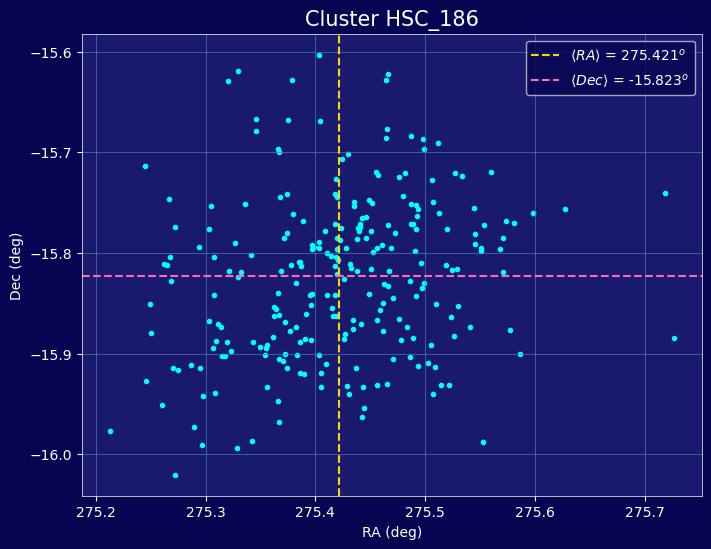

In [92]:
plt.figure(figsize = (8,6))
plt.scatter(my_cluster['RAdeg'], my_cluster['DEdeg'], color = 'cyan', marker='.')
plt.xlabel('RA (deg)')
plt.ylabel('Dec (deg)')
plt.axvline(np.mean(my_cluster['RAdeg']), ls = 'dashed', color = 'gold', label = f'$\langle RA \\rangle$ = {np.mean(my_cluster["RAdeg"]):.3f}$^o$')
plt.axhline(np.mean(my_cluster['DEdeg']), ls = 'dashed', color = 'hotpink', label = f'$\langle Dec \\rangle$ = {np.mean(my_cluster["DEdeg"]):.3f}$^o$')
plt.legend()
plt.title('Cluster HSC_186', fontsize = 15)

c. Answer: Given these results, there is evidence that the populations of stars which each subsample is drawn from *is* different from the other subsample, evidenced by the statistically significant values in the right-ascension subsamples. 
* For the **RA** results: parallax, proper motion (both in RA and Dec) and the photometric BP-RP have $p$-values of less than 0.05, which I defined as my threshold for significance, suggesting that for those parameters, I can reject the null hypothesis in 4 out of 5 parameters. 
* For the **Dec** results: only proper motion in declination has a $p$-value less than the threshold, so I can reject the null hypothesis in 1 out of 5 parameters. 

Thus there is some evidence for change with position in the cluster. 

* *Identify one test result that you believe may not reflect reality. Fill in the blanks in this sentence: “This test is misleading because the histograms in Figure ___ show ___, which violates the assumption of ___.” If you don’t believe any test results are in conflict with what you see in the Figures, fill in the blanks in the following sentence. “No tests are misleading. For example, the histograms in Figure ___ show ___, which is in line with the assumption of ___ required by the t-test.”* 

    * Overall, I don't think that the t-statistic is appropriate here because it requires the assumption that the observations are independent random samples -- technically they are not random, as they are already filtered in relation to the mean values of RA and Dec (just sides of the cluster). 
    * One test that I believe may not reflect reality is the p-value on the `Gmag` parameter. This test is misleading because 
    - RA comparison Histogram has Gmag:
        - $\mu_{subset, low} < \mu_{overall} < \mu_{subset, high}$
        - which means that moving from left to right, the cluster is brighter in the G band.
    - Dec comparison histogram has Gmag:
        - $\mu_{subset, high} < \mu_{overall} < \mu_{subset, low}$
        - which means that moving from top to bottom, the cluster is brighter in the G band
    - I think this directly violates the assumption that the data is normally distributed if there is this kind of trend in the brightness
    - also, we know that the BP-RP band is actually contained within the G-band. It seems also unrealistic that the G-band should not have some statistically significant change across position when BP-RP does for the RA subsamples.

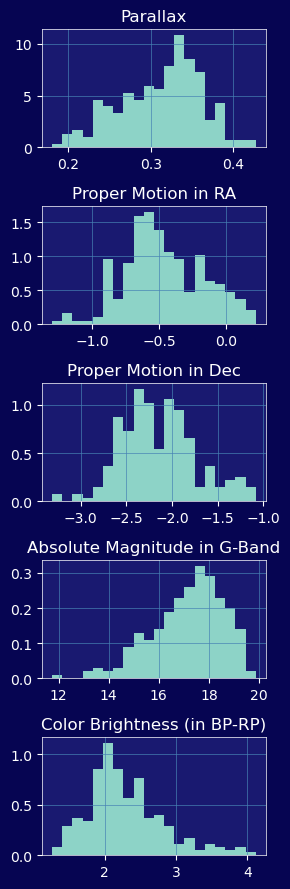

In [103]:
fig, ax = plt.subplots(5, 1, figsize = (3,9))
ax[0].hist(my_cluster['Plx'], density = True, bins = 20, label = 'Plx')
ax[0].set_title('Parallax')
ax[1].hist(my_cluster['pmRA'], density = True, bins = 20)
ax[1].set_title('Proper Motion in RA')
ax[2].hist(my_cluster['pmDE'], density = True, bins = 20)
ax[2].set_title('Proper Motion in Dec')
ax[3].hist(my_cluster['Gmag'], density = True, bins = 20)
ax[3].set_title('Absolute Magnitude in G-Band')
ax[4].hist(my_cluster['BP-RP'], density = True, bins = 20)
ax[4].set_title('Color Brightness (in BP-RP)')
plt.tight_layout()

***d.** Based on the parameter distributions you plot, is the t-test an appropriate test in all cases?*

# COME BACK TO THIS

I don't think the t-test is an appropriate test for this hypothesis testing in general, given that the data seems to violate three of the four main requirements: 
1. not independent and random
2. not normally distributed
3. variances of the groups, although we're told to assume populations with the same variance, seems to be questionable in the assumption that they are the same, just by looking at the structure of the cluster (Dec vs. RA), more outliers along RA = different variance 

The only aspect satisfied is that the data is a continuous variable. 

Also, we learned in class that for this to work, under the null hypothesis (equal sample means) the test statistic follows a student-t distribution. However I don't fully believe that can be true here, because even if the sample means for a certain parameter were equal, I still don't think that the student-t distribution would be a reasonable model given that this is a real star cluster with a non-uniform distribution. 

----------------------------------------------------------------

## 3. Hypothesis testing (7 pts): Now you will analyse all the clusters in your new sample (i.e. star counts > 200, constrained in RA and Dec standard deviation).
*a. Before computing any p-values, choose exactly one expectation about the distribution of p-values across your sample of clusters, based on the table below (include your expectations in your Jupyter notebook). Justify your choices, each in one sentence. Reference one figure or observation from a previous exercise to justify your expectation.*

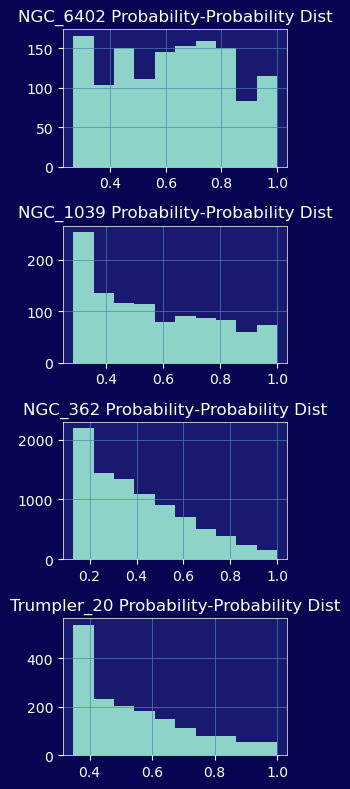

In [118]:
orig_clusters = ['NGC_6402', 'NGC_1039', 'NGC_362', 'Trumpler_20']
fig, ax = plt.subplots(4, 1, figsize = (3,8))
for (i, cluster) in enumerate(orig_clusters): 
    ax[i].hist(stars[stars['Name']==cluster]['Prob'])
    ax[i].set_title(f'{cluster} Probability-Probability Dist')
plt.tight_layout()

- Plx (RA split): skewed high; this is based on the fact that the plot for NGC_6402 in my scatter plot matrix (exercise 1) was skewed higher (more spread out to the right) and was the only one with a a higher amount of stars in the cluster with a high probability of being in the cluster (so more representative of this new sample of clusters). 
- pmRA (RA split): uniform, based on the plots in exercise 1. pmRA and RA are intrinsically linked. 
- BP-RP (Dec split): skewed high. I don't know !!!!! 

In [121]:
# Back to this table: 
print('cluster high probability greater than 200 and standard deviations less than 0.1:')
print(f'len: {len(clhp_gt200_stdltp1)}')
clhp_gt200_stdltp1 

cluster high probability greater than 200 and standard deviations less than 0.1:
len: 45


,Name,count,sd_RAdeg,sd_DEdeg
4783,NGC_6656,1767,0.067718,0.069157
4678,NGC_6121,1504,0.046694,0.041750
4731,NGC_6397,1494,0.081423,0.046758
4691,NGC_6205,806,0.063549,0.041828
4600,NGC_3201,747,0.056409,0.037390
4808,NGC_6809,709,0.043761,0.038902
4694,NGC_6218,658,0.032725,0.030468
4664,NGC_5904,580,0.038929,0.035678
4718,NGC_6341,467,0.044820,0.035705
4758,NGC_6544,416,0.041062,0.041286


*Control test: Before looking for spatial variation, validate your method. For every cluster,
randomly shuffle the stars into two groups (ignoring RA/Dec) and perform the t-test on
pmRA. Plot the histogram of these p-values. Self-Check: If this histogram is not roughly
uniform, debug your code before proceeding.*

In [124]:
rng = np.random.default_rng(seed = 12345)

In [127]:
stars['Name']

0            1636-283
1            1636-283
2            1636-283
3            1636-283
4            1636-283
              ...    
1291924    vdBergh_92
1291925    vdBergh_92
1291926    vdBergh_92
1291927    vdBergh_92
1291928    vdBergh_92
Name: Name, Length: 1291929, dtype: object

In [128]:
clhp_gt200_stdltp1['Name']

4783         NGC_6656
4678         NGC_6121
4731         NGC_6397
4691         NGC_6205
4600         NGC_3201
4808         NGC_6809
4694         NGC_6218
4664         NGC_5904
4718         NGC_6341
4758         NGC_6544
4641         NGC_5272
6070       Trumpler_5
4702         NGC_6254
4729         NGC_6388
4560         NGC_2477
4589         NGC_2808
4815         NGC_6838
4489         NGC_2158
4484         NGC_2099
4795         NGC_6723
4757         NGC_6541
4724         NGC_6362
4707         NGC_6273
4804         NGC_6791
4843         NGC_7089
4840         NGC_7078
2533          HSC_186
4696         NGC_6231
1327    Collinder_261
4773         NGC_6626
4802         NGC_6760
4488         NGC_2141
4423      Melotte_105
161             BH_66
4534         NGC_2360
4593          NGC_288
1315    Collinder_110
4588         NGC_2682
4630         NGC_4755
6052      Trumpler_19
4725         NGC_6366
4734         NGC_6402
4720         NGC_6352
6059      Trumpler_25
6124          UBC_106
Name: Name

In [131]:
new_subset = stars[stars['Name'].isin(clhp_gt200_stdltp1['Name'])]
new_subset

,Name,ID,GaiaDR3,inrt,Prob,RAdeg,e_RAdeg,DEdeg,e_DEdeg,GLON,...,o_RVd,GRVSmag,e_GRVSmag,o_GRVSmag,Vbroad,e_Vbroad,o_Vbroad,VarFlag,NSS,RVS
28483,BH_66,137,5310470909654483968,1,0.857535,141.250168,0.083338,-54.723593,0.085577,275.976532,...,0.0,0.000000,0.000000,0.0,0.00000,0.00000,0.0,NOT_AVAILABLE,0,0
28484,BH_66,137,5310470879618864000,1,0.968348,141.250079,0.049766,-54.733814,0.052596,275.983645,...,0.0,0.000000,0.000000,0.0,0.00000,0.00000,0.0,NOT_AVAILABLE,0,0
28485,BH_66,137,5310470909654487808,1,0.825867,141.259606,0.205586,-54.718497,0.202547,275.976873,...,0.0,0.000000,0.000000,0.0,0.00000,0.00000,0.0,NOT_AVAILABLE,0,0
28486,BH_66,137,5310470982672860672,1,0.875486,141.235645,0.254661,-54.713470,0.250442,275.963439,...,0.0,0.000000,0.000000,0.0,0.00000,0.00000,0.0,NOT_AVAILABLE,0,0
28487,BH_66,137,5310470944014218752,1,0.786216,141.239278,0.050103,-54.728510,0.050590,275.975465,...,0.0,0.000000,0.000000,0.0,0.00000,0.00000,0.0,NOT_AVAILABLE,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1194174,UBC_106,6119,4253500112699787392,1,0.681309,280.339794,0.013737,-5.569842,0.013181,26.827862,...,0.0,0.000000,0.000000,0.0,0.00000,0.00000,0.0,NOT_AVAILABLE,0,0
1194175,UBC_106,6119,4253500078340016256,1,0.670781,280.356320,0.012202,-5.567600,0.011660,26.837382,...,2.0,11.441406,0.068224,7.0,376.27792,73.67611,6.0,NOT_AVAILABLE,0,1
1194176,UBC_106,6119,4253499940900973440,1,0.800403,280.397404,0.016751,-5.570289,0.016592,26.853702,...,0.0,0.000000,0.000000,0.0,0.00000,0.00000,0.0,NOT_AVAILABLE,0,0
1194177,UBC_106,6119,4253500147059545344,1,0.670706,280.343337,0.039917,-5.557633,0.038934,26.840331,...,0.0,0.000000,0.000000,0.0,0.00000,0.00000,0.0,NOT_AVAILABLE,0,0


In [133]:
rng = np.random.default_rng(seed = 12345)


In [ ]:
for i, cluster in enumerate(clhp_gt200_stdltp1['Name']): 
    rng.shuffle()

In [123]:
rng

Generator(PCG64) at 0x3A18717E0

In [120]:
np.random.default_rng?

Docstring:
default_rng(seed=None)
Construct a new Generator with the default BitGenerator (PCG64).

    Parameters
    ----------
    seed : {None, int, array_like[ints], SeedSequence, BitGenerator, Generator}, optional
        A seed to initialize the `BitGenerator`. If None, then fresh,
        unpredictable entropy will be pulled from the OS. If an ``int`` or
        ``array_like[ints]`` is passed, then it will be passed to
        `SeedSequence` to derive the initial `BitGenerator` state. One may also
        pass in a `SeedSequence` instance.
        Additionally, when passed a `BitGenerator`, it will be wrapped by
        `Generator`. If passed a `Generator`, it will be returned unaltered.

    Returns
    -------
    Generator
        The initialized generator object.

    Notes
    -----
    If ``seed`` is not a `BitGenerator` or a `Generator`, a new `BitGenerator`
    is instantiated. This function does not manage a default global instance.

    See :ref:`seeding_and_entropy` 

#### Control test -- 

In [ ]:
# first randomly sort them into two groups 

for (i, cluster) in enumerate(clhp_gt200_stdltp1['Name']):
    
